In [1]:
import json, os, warnings
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from itertools import accumulate
from datetime import date, datetime

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib import rc
%matplotlib inline

import scipy
import scipy.stats

from binning import *

rc('text', usetex=False)
rc('font', family='serif')
rc('font', serif=['Times New Roman', 'Times'])
mpl.rcParams['mathtext.fontset'] = 'stix'

color0 = '#4286f4'
colorA = '#FD8208'

In [2]:
FONT_SCALE = 1.5
SAVE_DPI = 300
FIG_DIR = "Figures"

HIST_RATIOS = []

def fs(x):
    return round(x * FONT_SCALE)

def savefig(fig, name):
    import os
    os.makedirs(FIG_DIR, exist_ok=True)
    fig.savefig(os.path.join(FIG_DIR, name), dpi=SAVE_DPI, bbox_inches='tight')
    if HIST_RATIOS and HIST_RATIOS[-1]['panel'] is None:
        HIST_RATIOS[-1]['panel'] = name.replace('.pdf', '')

def sci_yaxis(ax=None, exp=None, n_ticks=4, xpow_x=0.0, xpow_y=1.00,
              fontsize_tick=None, fontsize_ann=None):
    import matplotlib.ticker as mticker
    ax = ax or plt.gca()
    ft = fs(30) if fontsize_tick is None else fontsize_tick
    fa = fs(20) if fontsize_ann is None else fontsize_ann
    ymin, ymax = ax.get_ylim()
    if exp is None:
        exp = int(round(np.log10(ymax))) if ymax > 0 else 0
    f = 10.0 ** exp
    locs = [l for l in mticker.MaxNLocator(n_ticks).tick_values(max(ymin, 0.0), ymax)
            if 0 < l <= ymax]
    ax.set_yticks(locs)
    ax.set_yticklabels([r'${:.1f}$'.format(l / f) for l in locs], fontsize=ft)
    ax.annotate(r'$\times 10^{%d}$' % exp, xy=(xpow_x, xpow_y), xycoords='axes fraction',
                fontsize=fa, ha='left', va='bottom', annotation_clip=False)
    return exp

def moving_average(a, n=1):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

def mean_confidence_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), scipy.stats.sem(a)
    h = se * scipy.stats.t.ppf((1 + confidence) / 2., n - 1)
    return m, h

def make_color_by_value(vmin, vmax, cmap=None):
    cmap = cmap or plt.cm.jet
    norm = Normalize(vmin=vmin, vmax=vmax, clip=True)

    def color(x):
        return cmap(norm(x))

    color.norm = norm
    color.cmap = cmap
    return color

def add_value_colorbar(fig, ax, color_fn):
    sm = ScalarMappable(norm=color_fn.norm, cmap=color_fn.cmap)
    sm.set_array([])
    return fig.colorbar(sm, ax=ax)

def build_id_time(events, maxyear, min_starts, min_event_year=None):
    id_time_all = defaultdict(list)
    for entity, start, end in events:
        d1, d2 = int(start), int(end)
        if d1 > maxyear:
            continue
        id_time_all[entity].append([d1, 1])
        if d2 <= maxyear:
            id_time_all[entity].append([d2, -1])

    id_time = {}
    for k, v in id_time_all.items():
        if sum(1 for _, s in v if s == 1) < min_starts:
            continue
        if min_event_year is not None and min(t for t, _ in v) < min_event_year:
            continue
        id_time[k] = v
    return id_time

def build_member_map(member_events, id_time):
    member_map = defaultdict(dict)
    for member, entity, start, end in member_events:
        if entity in id_time:
            member_map[member][entity] = [start, end]
    return dict(member_map)

def build_entity_members(member_map):
    entity_members = defaultdict(set)
    for member, ents in member_map.items():
        for entity in ents:
            entity_members[entity].add(member)
    return dict(entity_members)

def cumulative_population(id_time):
    per_step = defaultdict(int)
    for v in id_time.values():
        for t, situation in v:
            per_step[t] += situation
    ts = sorted(per_step)
    cum = dict(zip(ts, accumulate(per_step[t] for t in ts)))
    return dict(per_step), cum

def growth_curve(events_v, cum_population):
    net = defaultdict(int)
    for t, s in events_v:
        net[t] += s
    xs, ys, run = [], [], 0
    for t in sorted(net):
        run += net[t]
        xs.append(t)
        ys.append(run / cum_population[t])
    return xs, ys

def growth_curves_by_peak(id_time, cum_population, peak_after, length=1,
                          bar=None, keep=None):
    plot_all = {}
    for v in id_time.values():
        xs, ys = growth_curve(v, cum_population)
        yd = moving_average(ys, n=length)
        xd = xs[length - 1:]
        if xd[int(np.argmax(yd))] <= peak_after:
            continue
        peak_height = max(yd)
        if keep == 'below' and peak_height > bar:
            continue
        if keep == 'above' and peak_height <= bar:
            continue
        peak_time = xs[ys.index(max(ys))]
        plot_all.setdefault(peak_time, []).append((xd, yd))
    return plot_all

def draw_growth_curves(ax, plot_all, color_fn):
    keys = plot_all.keys()
    lo, hi = min(keys), max(keys)
    for peak_time in range(lo, hi):
        if peak_time not in plot_all:
            continue
        for xd, yd in plot_all[peak_time]:
            ax.plot(xd, yd, color=color_fn(peak_time), linewidth=4)

def compute_desertion_rates(id_time, time_transform=None, min_points=3,
                            startday_cum=5, verbose=True):
    day_P = defaultdict(list)
    slopelist = []
    id_day_current = {}

    for count, (k, v) in enumerate(id_time.items(), 1):
        if verbose and count % 10 == 0:
            print(count)
        if time_transform is not None:
            v = time_transform(v)

        period = sorted(Counter(x[0] for x in v))
        firstday, lastday = period[0], period[-1]
        id_day_current[k] = {}

        day_adoption = Counter(x[0] for x in v if x[1] == 1)
        day_desertion = Counter(x[0] for x in v if x[1] == -1)

        current = cum = 0
        startday = None
        timeline = {}
        for i in range(firstday, lastday + 1):
            desertion = day_desertion.get(i, 0)
            current += day_adoption.get(i, 0) - desertion
            timeline[i] = [desertion, current]
            cum += desertion
            if startday is None and cum >= startday_cum:
                startday = i
        if startday is None:
            continue

        X_Y_freq = []
        for i in range(startday + 1, lastday + 1):
            desertion = timeline[i][0]
            previous = timeline[i - 1][1]
            day_P[i - startday].append(desertion / (previous + 1))
            id_day_current[k][i] = timeline[i][1]
            X_Y_freq.append([i, 1, desertion])
            X_Y_freq.append([i, 0, previous - desertion])

        if min_points is not None and len(X_Y_freq) < min_points:
            continue
        X_Y_freq = np.array(X_Y_freq)
        x, y, w = X_Y_freq[:, 0], X_Y_freq[:, 1], X_Y_freq[:, 2]
        n_samp = w.sum()
        s_x, s_y = np.dot(x, w), np.dot(y, w)
        s_xy, s_xx = np.dot(x * y, w), np.dot(x * x, w)
        slope = (s_xy - s_x / n_samp * s_y) / (s_xx - s_x / n_samp * s_x)
        slopelist.append(slope)

    return dict(day_P), slopelist, id_day_current

def plot_nu_vs_t(day_P, max_t, bin_step=1, lin_bins=10, figsize=(5, 5)):
    kmax = max(day_P)
    xlist, ylist, stdlist = [], [], []
    for t in range(1, kmax + 1, bin_step):
        if t > max_t:
            break
        ys = []
        for j in range(bin_step):
            if t + j in day_P:
                ys.extend(day_P[t + j])
        if not ys:
            continue
        m, h = mean_confidence_interval(ys)
        xlist.append(t)
        ylist.append(m)
        stdlist.append(h)
    xlist, ylist, stdlist = map(np.array, (xlist, ylist, stdlist))

    fig = plt.figure(figsize=figsize)
    xs, ys = linear_binningtwo(list(xlist), list(ylist), lin_bins)
    plt.plot(xs, ys, 'o', color='grey', markersize=8, alpha=0.5, label='average')
    plt.fill_between(xlist, ylist - stdlist, ylist + stdlist,
                     alpha=0.2, facecolor='grey', antialiased=True)
    return fig, (xlist, ylist, stdlist)

def two_color_hist(values, gap, threshold=0.0,
                   pos_color='#4286f4', figsize=(5, 5)):
    temp = sorted(values)
    lo, hi = min(temp), max(temp)

    left = threshold - np.ceil((threshold - lo) / gap) * gap
    right = threshold + np.ceil((hi - threshold) / gap) * gap
    bins = np.arange(left, right + gap / 2, gap)
    if not np.any(np.isclose(bins, threshold)):
        bins = np.sort(np.append(bins, threshold))
    heights, bins = np.histogram(temp, bins=bins, density=True)
    widths = np.diff(bins)
    bin_pos = (bins[:-1] + bins[1:]) / 2
    mask = bin_pos >= threshold

    fig = plt.figure(figsize=figsize)
    plt.bar(bin_pos[mask], heights[mask], width=widths[mask], color=pos_color,
            alpha=0.8, edgecolor='k', linewidth=1, label='$>0$')
    plt.bar(bin_pos[~mask], heights[~mask], width=widths[~mask], color='grey',
            alpha=0.2, edgecolor='k', linewidth=1, label='$<=0$')
    ratio = len([x for x in temp if x > threshold]) / len(temp)
    print('{:.2%}'.format(ratio))
    HIST_RATIOS.append({'panel': None, 'n': int(len(temp)), 'pct_positive': round(100 * ratio, 4)})
    return fig, ratio

def embeddedness_analysis(id_time, id_day_current, cum_population,
                          build_nodelist, half_frac=0.5, peak_normalized=True,
                          window=(0, 1), window_cap=None, verbose=True):
    r0list, rnlist, slopelist_pvalue = [], [], []

    for count, (sample, v) in enumerate(id_time.items(), 1):
        if verbose and count % 10 == 0:
            print(count)

        period = sorted(id_day_current[sample])
        if not period:
            continue
        if peak_normalized:
            current = {k: id_day_current[sample][k] / (cum_population[k] + 1)
                       for k in period}
        else:
            current = {k: id_day_current[sample][k] for k in period}

        peak = max(current.values())
        peakday = max(current, key=current.get)
        if peakday == max(period):
            continue

        halfday = None
        for day in sorted(d for d in period if d > peakday):
            if current[day] < peak * half_frac:
                halfday = day
                break
        if halfday is None:
            continue

        win = [halfday + window[0], halfday + window[1]]
        if window_cap is not None:
            if win[1] > window_cap:
                continue
        elif win[1] > max(period):
            continue

        nodelist = build_nodelist(sample, win)
        width = win[1] - win[0]

        count0 = Counter(x[2] for x in nodelist if x[1] == 0)
        if count0[0] + count0[1] == 0:
            continue
        rate0 = count0[1] / (count0[0] + count0[1]) / width

        countn = Counter(x[2] for x in nodelist if x[1] > 0)
        if countn[0] + countn[1] == 0:
            continue
        raten = countn[1] / (countn[0] + countn[1]) / width

        if rate0 + raten == 0:
            r0list.append(1)
            rnlist.append(1)
        else:
            avg = (rate0 + raten) / 2
            r0list.append(rate0 / avg)
            rnlist.append(raten / avg)

        slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(
            [x[1] for x in nodelist], [x[2] for x in nodelist])
        slopelist_pvalue.append((slope, p_value))

    return r0list, rnlist, slopelist_pvalue

def single_sample_rate_by_r(sample, id_day_current, cum_population,
                            build_nodelist, half_frac=0.5, peak_normalized=True,
                            window=(0, 1), min_count=10, max_r=30,
                            period_filter=None):
    period = sorted(id_day_current[sample])
    if period_filter is not None:
        period = period_filter(period)
    if peak_normalized:
        current = {k: id_day_current[sample][k] / (cum_population[k] + 1) for k in period}
    else:
        current = {k: id_day_current[sample][k] for k in period}

    peak = max(current.values())
    peakday = max(current, key=current.get)
    halfday = None
    for day in sorted(d for d in period if d > peakday):
        if current[day] < peak * half_frac:
            halfday = day
            break
    if halfday is None:
        raise ValueError(
            f"sample {sample!r} never drops below {half_frac}*peak after its "
            f"peak; pick a different worked-example entity or adjust half_frac.")
    win = [halfday + window[0], halfday + window[1]]
    width = win[1] - win[0]

    nodelist = build_nodelist(sample, win)
    r_rate, avlist = {}, []
    for r in range(max_r):
        c = Counter(x[2] for x in nodelist if x[1] == r)
        if c[1] + c[0] < min_count:
            continue
        rate = c[1] / (c[0] + c[1]) / width
        r_rate.setdefault(r, []).append(rate)
        avlist.append(rate)
    return r_rate, avlist, win

def make_collaborator_nodelist(entity_members, member_map, collaborator_year,
                               maxyear=None):
    def build(sample, win):
        nodelist = []
        for p in entity_members.get(sample, ()):
            if p not in member_map or sample not in member_map[p]:
                continue
            adopt = int(member_map[p][sample][0])
            desert = int(member_map[p][sample][1])
            if maxyear is not None and desert > maxyear:
                continue
            if desert < win[0] or adopt > win[0]:
                continue
            temp = 0
            if p in collaborator_year:
                for f, fyear in collaborator_year[p].items():
                    if (f in member_map and sample in member_map[f]
                            and int(member_map[f][sample][1]) <= win[0]
                            and fyear <= adopt):
                        temp += 1
            nodelist.append([p, temp, 1 if desert <= win[1] else 0])
        return nodelist
    return build

def make_drug_nodelist(mechanism_org, org_mech_timeSE, org_similarity,
                       sim_threshold=0.1):
    def build(mechanism, win):
        nodelist = []
        for o in mechanism_org[mechanism]:
            if o not in org_mech_timeSE or mechanism not in org_mech_timeSE[o]:
                continue
            for trial in org_mech_timeSE[o][mechanism]:
                adopt, desert = int(trial[0]), int(trial[1])
                if desert < win[0] or adopt > win[0]:
                    continue
                temp = 0
                if o in org_similarity:
                    for f, s in org_similarity[o].items():
                        if s <= sim_threshold:
                            continue
                        if f in org_mech_timeSE and mechanism in org_mech_timeSE[f]:
                            temp += sum(1 for x in org_mech_timeSE[f][mechanism]
                                        if int(x[1]) <= win[0])
                nodelist.append([o, temp, 1 if desert <= win[1] else 0])
        return nodelist
    return build

def make_phone_nodelist(entity_members, person_id_time, person_friend,
                        desert_cap=3590):
    def build(sample, win):
        nodelist = []
        for p in entity_members[sample]:
            adopt = person_id_time[p][sample][0]
            desert = person_id_time[p][sample][1]
            if desert > desert_cap or desert < win[0] or adopt > win[0]:
                continue
            temp = 0
            if p in person_friend:
                for f in person_friend[p]:
                    if (f in person_id_time and sample in person_id_time[f]
                            and win[0] >= person_id_time[f][sample][1]):
                        temp += 1
            nodelist.append([p, temp, 1 if desert <= win[1] else 0])
        return nodelist
    return build

def plot_rate_ratio_hist(r0list, rnlist, bins=20, ylim=2.5,
                         pos_color="#FD8208", figsize=(9, 9)):
    fig = plt.figure(figsize=figsize)
    plt.hist(r0list, bins=bins, density=True, histtype="bar", color='grey',
             alpha=0.5, edgecolor='w', label=r'$\nu/\bar\nu(r=0)$')
    plt.hist(rnlist, bins=bins, density=True, histtype="bar", color=pos_color,
             alpha=0.6, edgecolor='w', label=r'$\nu/\bar\nu(r>0)$')
    plt.xlabel(r'$\nu/\bar\nu$', fontsize=fs(40))
    plt.ylabel(r'$P(\nu/\bar\nu)$', fontsize=fs(40))
    plt.xlim(0.2, 1.8)
    plt.ylim(0, ylim)
    plt.legend(fontsize=fs(20))
    plt.xticks([0.5, 1.0, 1.5], fontsize=fs(30))
    plt.yticks([0.5, 1.0, 1.5, 2.0], fontsize=fs(30))
    plt.tight_layout()
    return fig

FD = 'figure_data'
def _load_slopes(p): return list(np.atleast_1d(np.loadtxt(f'{FD}/{p}.txt')))
def _load_ratio(p):
    a = np.atleast_2d(np.loadtxt(f'{FD}/{p}.txt'))
    return list(a[:,0][np.isfinite(a[:,0])]), list(a[:,1][np.isfinite(a[:,1])])
def _load_bars(p):
    a = np.atleast_2d(np.loadtxt(f'{FD}/{p}.txt'))
    bl = float(open(f'{FD}/{p}.txt').readline().split('baseline=')[1])
    return list(a[:,0]), list(a[:,1]), bl
def _load_growth(p):
    a = np.atleast_2d(np.loadtxt(f'{FD}/{p}.txt')); d = {}
    for cid in np.unique(a[:,0]):
        m = a[:,0]==cid; d.setdefault(int(a[m,1][0]), []).append((list(a[m,2]), list(a[m,3])))
    return d
def _load_growth_dates(p):
    a = np.atleast_2d(np.loadtxt(f'{FD}/{p}.txt')); d = {}
    for cid in np.unique(a[:,0]):
        m = a[:,0]==cid
        d.setdefault(int(a[m,1][0]), []).append([[date.fromordinal(int(x)) for x in a[m,2]], list(a[m,3])])
    return d
def _plot_nut(p, lin_bins=10, figsize=(5,5)):
    a = np.atleast_2d(np.loadtxt(f'{FD}/{p}.txt')); x,y,s = a[:,0], a[:,1], a[:,2]
    fig = plt.figure(figsize=figsize)
    xs, ys = linear_binningtwo(list(x), list(y), lin_bins)
    plt.plot(xs, ys, 'o', color='grey', markersize=8, alpha=0.5, label='average')
    plt.fill_between(x, y-s, y+s, alpha=0.2, facecolor='grey', antialiased=True)
    return fig


In [3]:
minyear, maxyear, bar = 1950, 2015, 0.028
color_fn = make_color_by_value(minyear, maxyear)

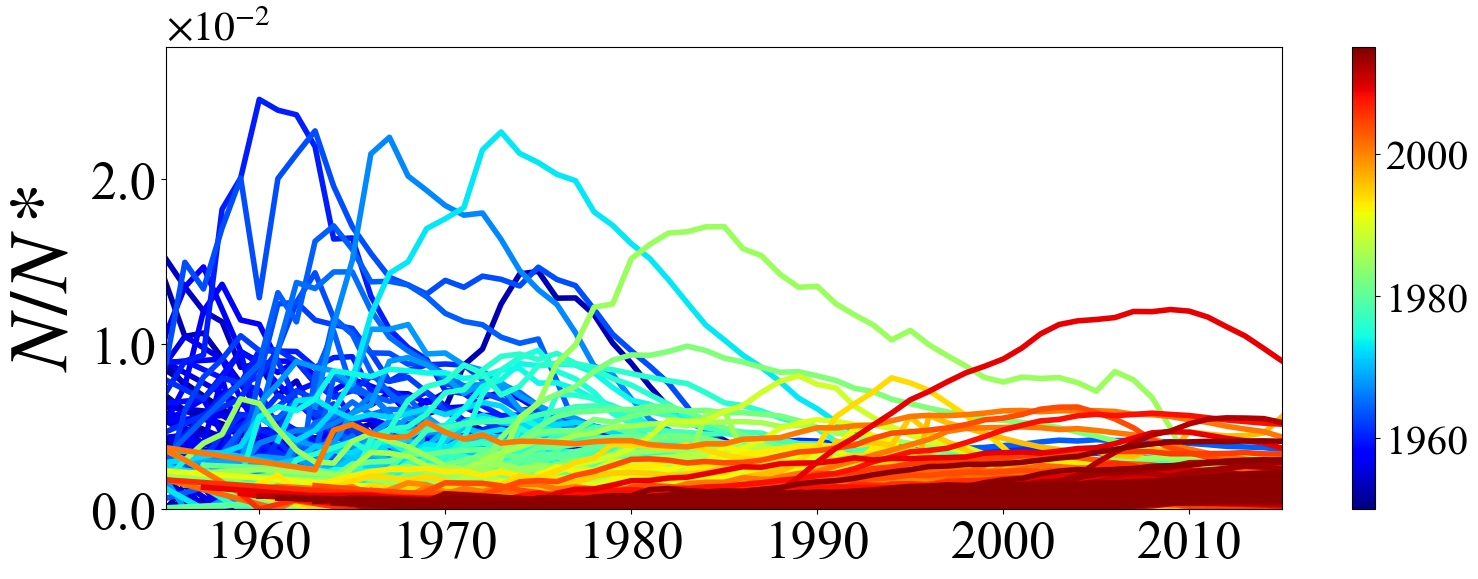

In [4]:
plot_all = _load_growth('scienceA1')
fig, ax = plt.subplots(figsize=(18, 6))
draw_growth_curves(ax, plot_all, color_fn)
plt.xlim(minyear + 5, maxyear); plt.ylim(0, bar)
plt.xticks([1960, 1970, 1980, 1990, 2000, 2010], size=fs(25))
plt.yticks([0, 0.01, 0.02], ['0.0', '1.0', '2.0'], size=fs(25))
plt.annotate(r'$\times 10^{-2}$', xy=(1955, bar), xytext=(1955, bar + 0.0005), fontsize=fs(20))
plt.ylabel('$N/N*$', fontsize=fs(40))
cbar = add_value_colorbar(fig, ax, color_fn)
cbar.ax.tick_params(labelsize=fs(20))
savefig(fig, 'scienceA1.pdf'); plt.show()

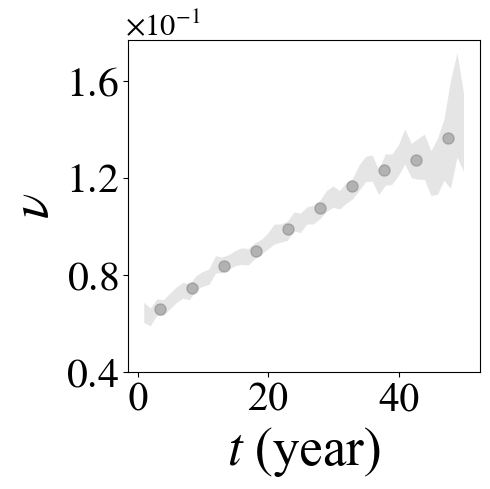

97.95%


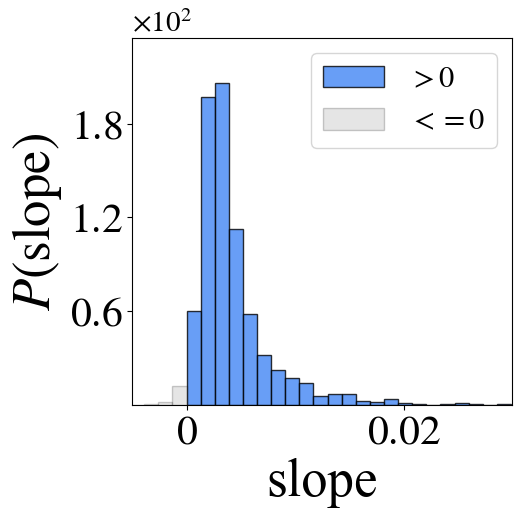

In [5]:

fig = _plot_nut('scienceA2')
plt.yticks([0.04, 0.08, 0.12, 0.16], ['$0.4$', '$0.8$', '$1.2$', '$1.6$'], fontsize=fs(20))
plt.annotate(r'$\times 10^{-1}$', xy=(-0.1, 0.177), xytext=(-2, 0.179), fontsize=fs(15))
plt.ylabel('$\\nu$', fontsize=fs(25)); plt.xlabel('$t$ (year)', fontsize=fs(25))
plt.xticks([0, 20, 40],fontsize=fs(20)); plt.tight_layout(); plt.show()
savefig(fig, 'scienceA2.pdf'); plt.show()

fig, ratio = two_color_hist(_load_slopes('scienceA3'), gap=0.0013, pos_color=color0, figsize=(5, 5))
plt.legend(fontsize=fs(15))
plt.xticks([0, 0.02], ['$0$', '$0.02$'], size=fs(20))
plt.ylabel('$P(\mathrm{slope})$', fontsize=fs(25)); plt.xlabel('slope', fontsize=fs(25))
plt.xlim(-0.005, 0.03)
plt.ylim(0, 235); plt.tight_layout()
sci_yaxis(xpow_x=0.0, xpow_y=1.0, fontsize_tick=fs(20), fontsize_ann=fs(14))
savefig(fig, 'scienceA3.pdf'); plt.show()

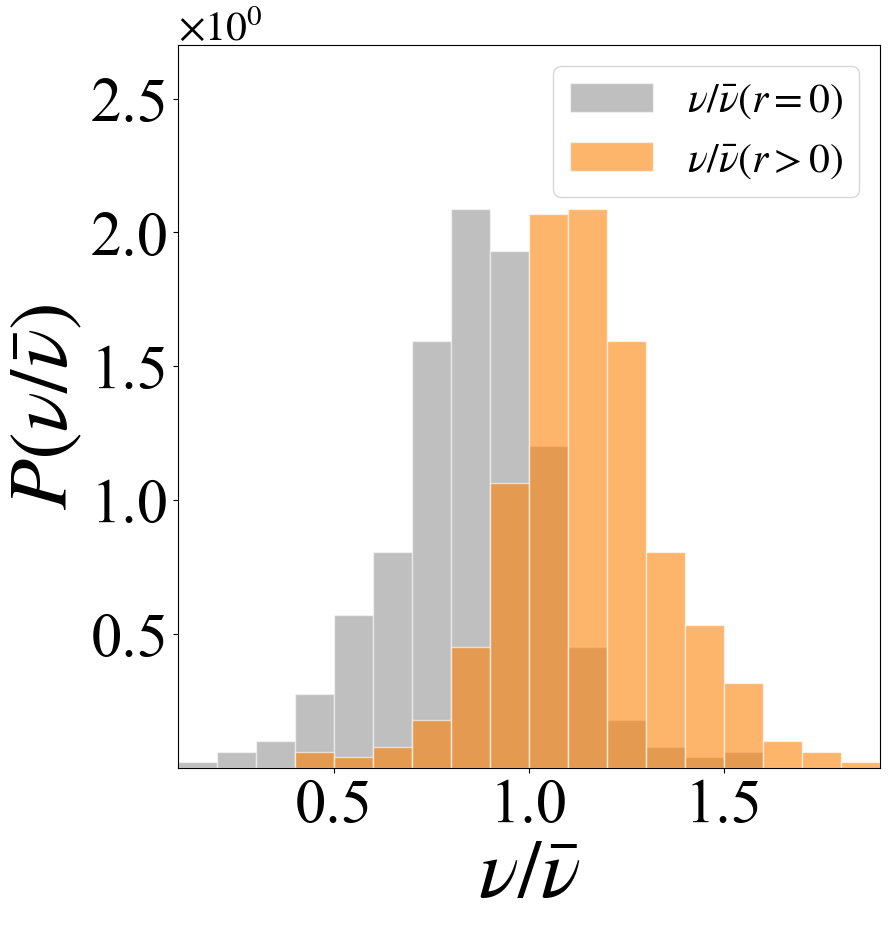

73.03%


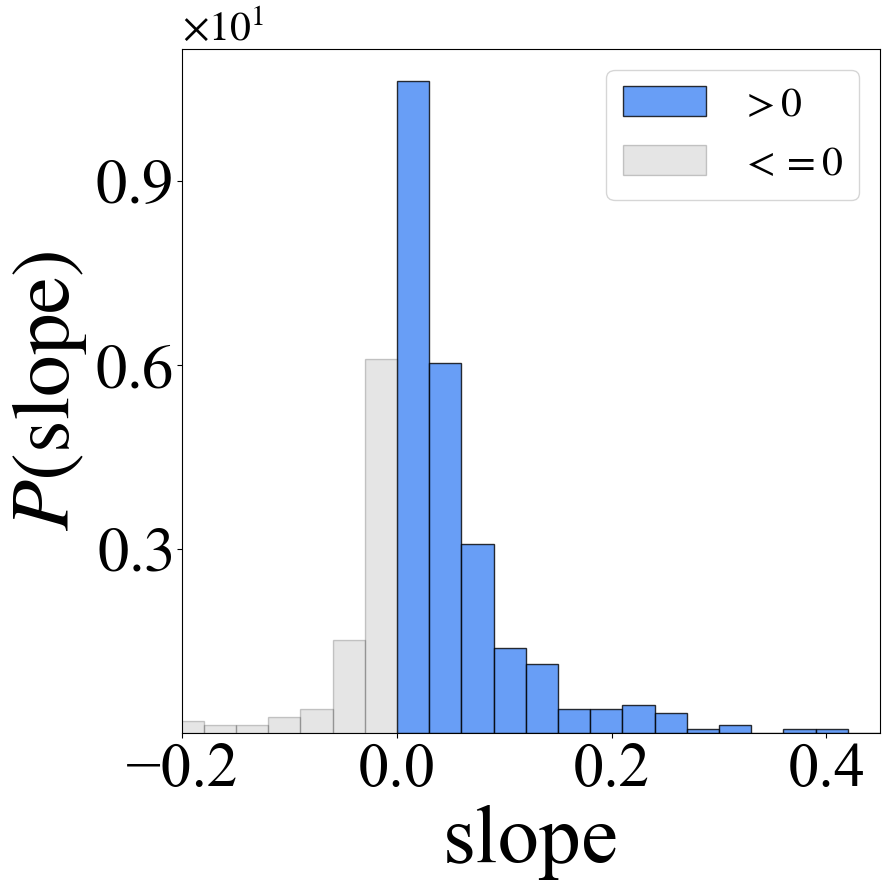

In [6]:

fig = plot_rate_ratio_hist(*_load_ratio('scienceB1'), ylim=2.7, pos_color=colorA)
plt.xlim(0.1, 1.9)
plt.xticks([0.5, 1.0, 1.5], fontsize=fs(30))
plt.yticks([0.5, 1.0, 1.5, 2.0, 2.5], fontsize=fs(30))
plt.annotate(r'$\times 10^{0}$', xy=(0.1, 2.7), xytext=(0.1, 2.72), fontsize=fs(20))
plt.legend (loc ='upper right', fontsize = fs(20))
savefig(fig, 'scienceB1.pdf'); plt.show()

fig, ratio = two_color_hist(_load_slopes('scienceB2'), gap=0.03, pos_color=color0, figsize=(9, 9))
plt.ylabel('$P(\mathrm{slope})$', fontsize=fs(40)); plt.xlabel('slope', fontsize=fs(40))
plt.legend(fontsize=fs(20)); plt.xlim(-0.2, 0.45)
plt.xticks([-0.2, 0, 0.2, 0.4],fontsize=fs(30))
sci_yaxis(xpow_x=0.0, xpow_y=1.0, fontsize_tick=fs(30), fontsize_ann=fs(20))
plt.tight_layout(); savefig(fig, 'scienceB2.pdf'); plt.show()

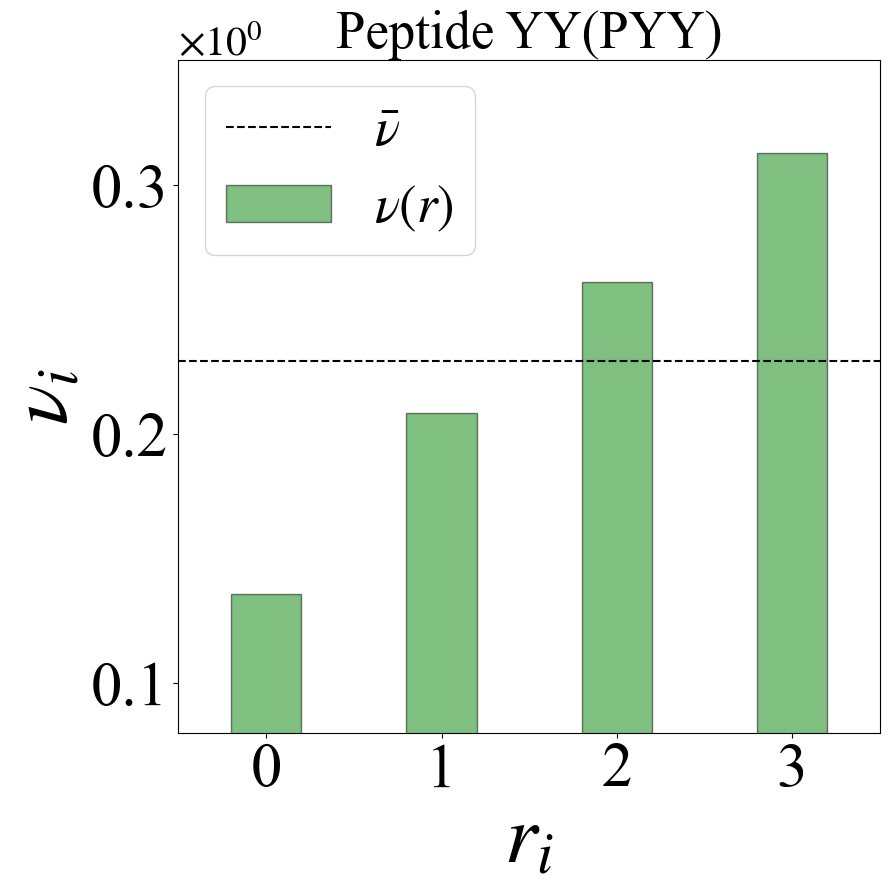

In [7]:
fig = plt.figure(figsize=(9, 9)); ax = plt.subplot(111)
xdata, ydata, av = _load_bars('scienceB3')
ax.bar(xdata, moving_average(ydata, n=1), color='green', edgecolor='k', alpha=0.5, width=0.4, label=r'$\nu(r)$')
left, right = -0.5, 3.5
ax.plot([left, right], [av, av], 'k--', label=r'$\bar \nu$')
ax.set_title('Peptide YY(PYY)', fontsize=fs(25))
ax.set_ylabel(r'$\nu_i$', fontsize=fs(40)); ax.set_xlabel('$r_i$', fontsize=fs(40))
ax.set_ylim(0.08, 0.35); ax.set_xlim(left, right)
plt.xticks([0, 1, 2, 3], fontsize=fs(30))
plt.yticks([0.1, 0.2, 0.3], ['0.1', '0.2', '0.3'], fontsize=fs(30))
ax.legend(loc=2, fontsize=fs(25))
plt.annotate(r'$\times10^{0}$', xy=(left, 0.35), xytext=(left, 0.352), fontsize=fs(20))
plt.tight_layout()
savefig(fig, 'scienceB3.pdf'); plt.show()

In [8]:
minyear, maxyear = 1980, 2018
color_fn = make_color_by_value(minyear, maxyear)

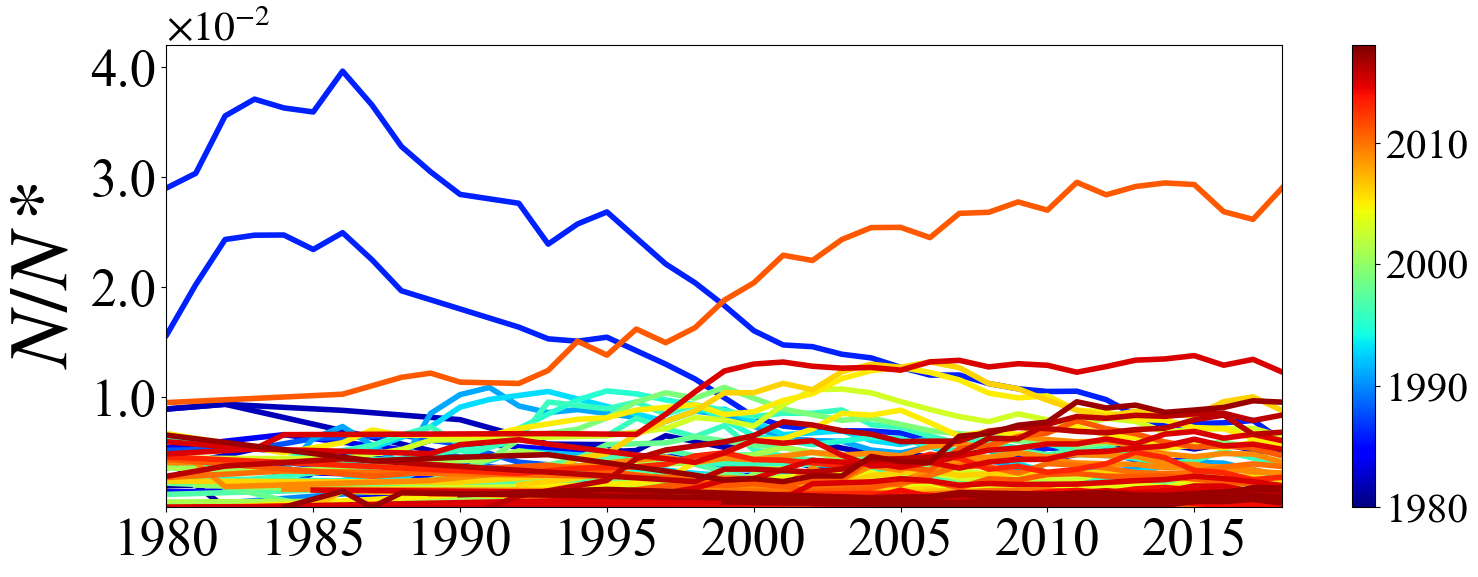

In [9]:
plot_all = _load_growth('drugA1')
fig, ax = plt.subplots(figsize=(18, 6))
draw_growth_curves(ax, plot_all, color_fn)
ymax = 0.042
plt.xlim(minyear, maxyear); plt.ylim(0, ymax)
plt.xticks(size=fs(25));
plt.yticks([0.01, 0.02, 0.03, 0.04], [ '1.0', '2.0', '3.0', '4.0'], size=fs(25))
plt.annotate(r'$\times10^{-2}$', xy=(minyear, ymax), xytext=(minyear, ymax + 0.0005), fontsize=fs(20))
plt.ylabel('$N/N*$', fontsize=fs(40))
cbar = add_value_colorbar(fig, ax, color_fn)
cbar.ax.tick_params(labelsize=fs(20))
savefig(fig, 'drugA1.pdf'); plt.show()

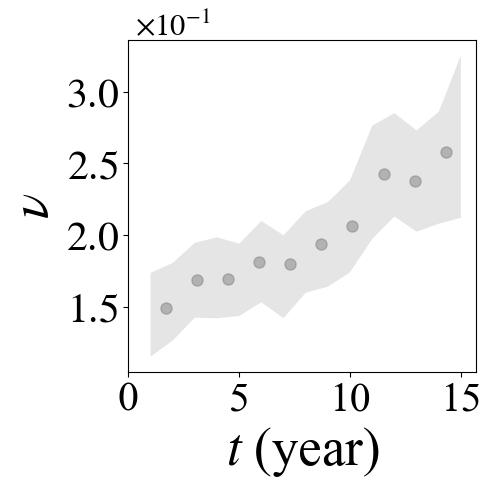

84.32%


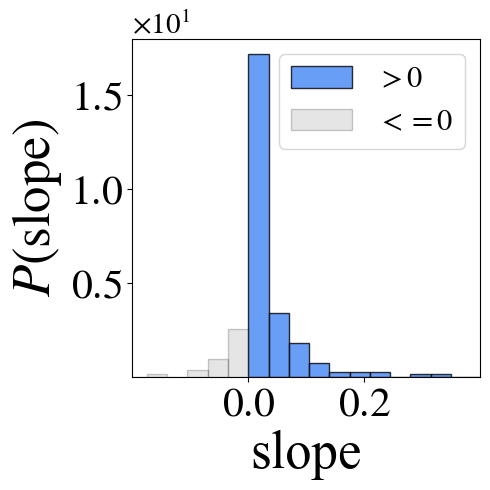

In [10]:

fig = _plot_nut('drugA2')

plt.ylabel('$\\nu$', fontsize=fs(25)); plt.xlabel('$t$ (year)', fontsize=fs(25))
plt.xticks([0, 5,10,15], fontsize=fs(20)); 
plt.yticks([0.15, 0.2, 0.25, 0.3],['$1.5$', '$2.0$', '$2.5$', '$3.0$'], fontsize=fs(20))

plt.annotate(r'$\times10^{-1}$', xy=(0.3, 0.33), xytext=(0.3, 0.34), fontsize=fs(15))
plt.tight_layout(); savefig(fig, 'drugA2.pdf'); plt.show()

fig, ratio = two_color_hist(_load_slopes('drugA3'), gap=0.035, pos_color=color0, figsize=(5, 5))
plt.legend(fontsize=fs(15))
plt.xticks([ 0.0, 0.2], ['$0.0$', '$0.2$'], fontsize=fs(30))
plt.ylabel('$P(\mathrm{slope})$', fontsize=fs(25)); plt.xlabel('slope', fontsize=fs(25))
plt.xlim(-0.2, 0.4); plt.xticks(fontsize=fs(20)); plt.ylim(0, 18)
sci_yaxis(xpow_x=0.0, xpow_y=1, fontsize_tick=fs(20), fontsize_ann=fs(14))
plt.tight_layout(); savefig(fig, 'drugA3.pdf'); plt.show()

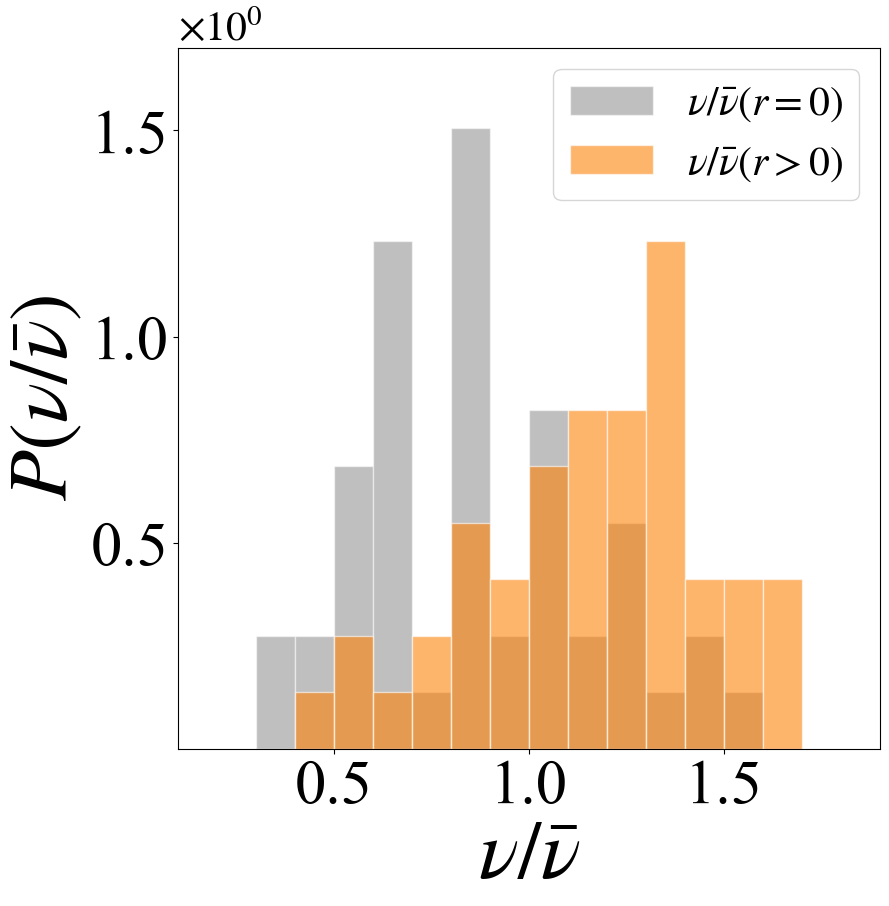

69.86%


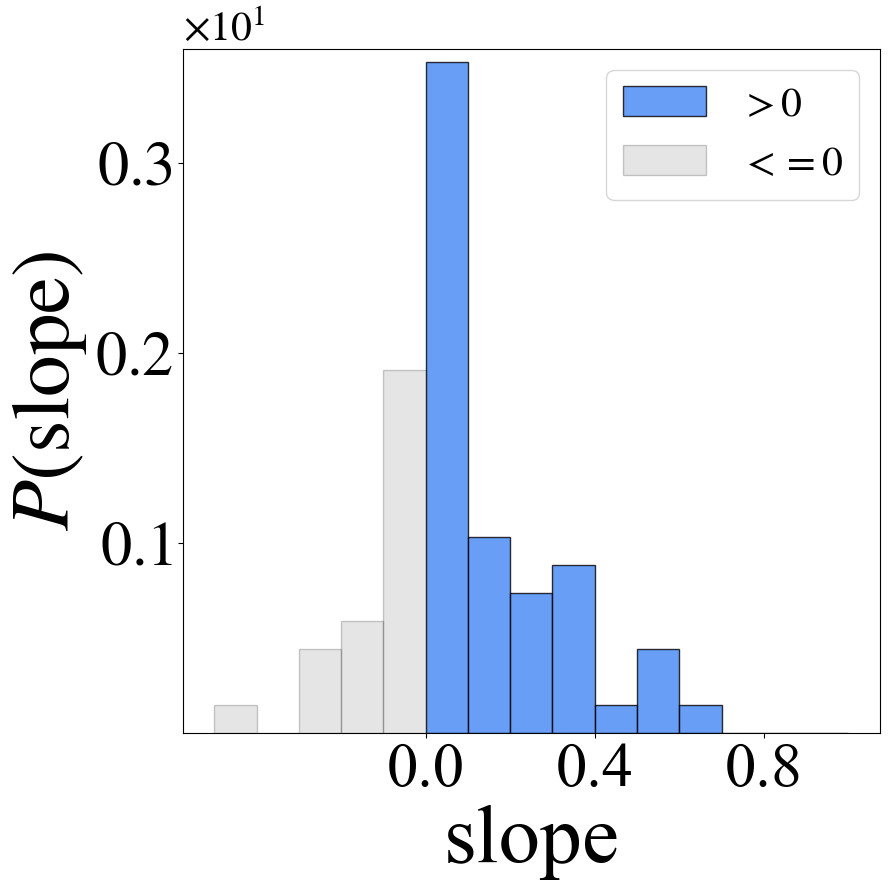

In [11]:

fig = plot_rate_ratio_hist(*_load_ratio('drugB1'), ylim=1.7, pos_color=colorA)
plt.xlim(0.1, 1.9)
plt.ylim(0, 1.7)
plt.xticks(fontsize=fs(30))
plt.yticks([0.5, 1.0, 1.5], fontsize=fs(30))
plt.annotate(r'$\times10^{0}$', xy=(0.1, 1.7), xytext=(0.1, 1.72), fontsize=fs(20))
savefig(fig, 'drugB1.pdf'); plt.show()

fig, ratio = two_color_hist(_load_slopes('drugB2'), gap=0.1, pos_color=color0, figsize=(9, 9))
plt.ylabel('$P(\mathrm{slope})$', fontsize=fs(40)); plt.xlabel('slope', fontsize=fs(40))
plt.legend(fontsize=fs(20))
plt.xticks([0, 0.4, 0.8], fontsize=fs(30))
plt.ylim(0,3.6)
plt.xticks(fontsize=fs(30))
sci_yaxis(xpow_x=0.0, xpow_y=1, fontsize_tick=fs(30), fontsize_ann=fs(20))
plt.tight_layout(); savefig(fig, 'drugB2.pdf'); plt.show()

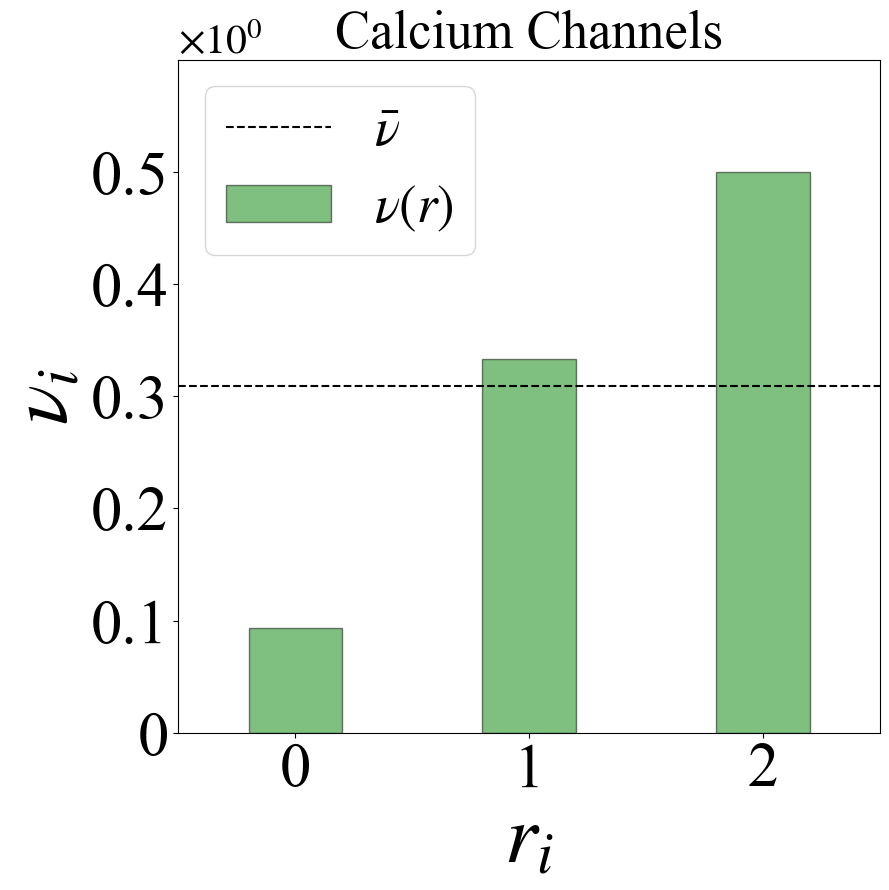

In [12]:
fig = plt.figure(figsize=(9, 9)); ax = plt.subplot(111)
xdata, ydata, av = _load_bars('drugB3')
ax.bar(xdata, ydata, color='green', edgecolor='k', alpha=0.5, width=0.4, label=r'$\nu(r)$')
left, right = -0.5, 2.5
ax.plot([left, right], [av, av], 'k--', label=r'$\bar \nu$')
ax.set_title('Calcium Channels', fontsize=fs(25))
ax.set_ylabel(r'$\nu_i$', fontsize=fs(40)); ax.set_xlabel('$r_i$', fontsize=fs(40))
ax.set_ylim(0, 0.6); ax.set_xlim(left, right)
plt.xticks([0, 1, 2], [0, 1, 2], fontsize=fs(30))
plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5], ['0', '0.1', '0.2', '0.3', '0.4', '0.5'], fontsize=fs(30))
ax.legend(loc=2, fontsize=fs(25))
plt.annotate(r'$\times10^{0}$', xy=(left, 0.5), xytext=(left, 0.606), fontsize=fs(20))
plt.tight_layout(); savefig(fig, 'drugB3.pdf'); plt.show()

In [13]:
minyear, maxyear = 1978, 2015
color_fn = make_color_by_value(minyear, maxyear)

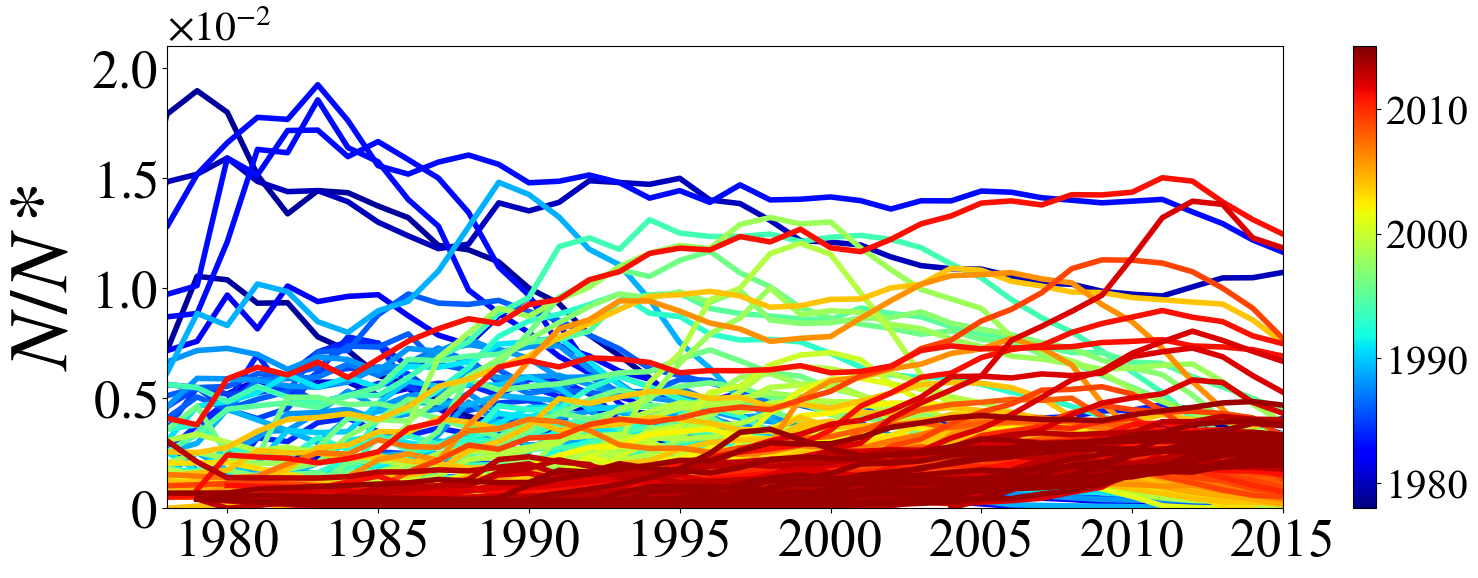

In [14]:
plot_all = _load_growth('patentA1')
fig, ax = plt.subplots(figsize=(18, 6))
draw_growth_curves(ax, plot_all, color_fn)
plt.xlim(minyear, maxyear); plt.ylim(0, 0.021)
plt.yticks([0, 0.005, 0.01, 0.015, 0.02], ['$0$', '$0.5$', '$1.0$', '$1.5$', '$2.0$'], size=fs(25)); plt.xticks(size=fs(25))
plt.annotate(r'$\times10^{-2}$', xy=(1978, 0.021), xytext=(1978, 0.0213), fontsize=fs(20))
plt.ylabel('$N/N*$', fontsize=fs(40))
cbar = add_value_colorbar(fig, ax, color_fn)
cbar.ax.tick_params(labelsize=fs(20))
savefig(fig, 'patentA1.pdf'); plt.show()

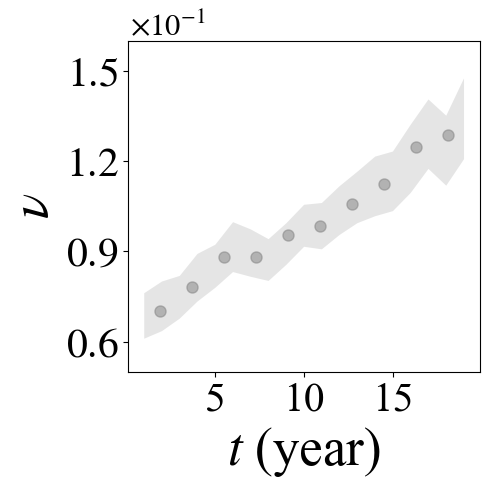

91.70%


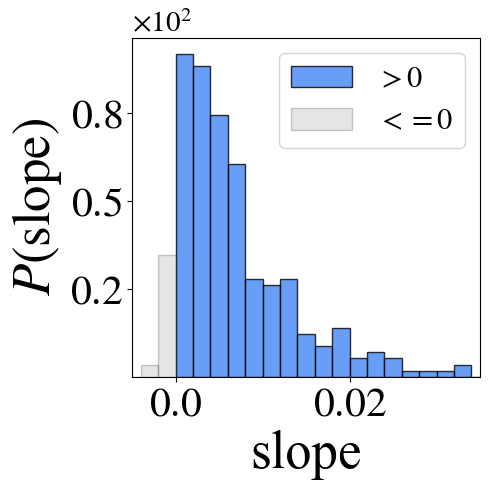

In [15]:

fig = _plot_nut('patentA2')
plt.ylabel('$\\nu$', fontsize=fs(25)); plt.xlabel('$t$ (year)', fontsize=fs(25))
plt.xticks([5, 10, 15],fontsize=fs(20))
plt.ylim(0.05, 0.16)
plt.yticks([0.06, 0.09, 0.12, 0.15],['$0.6$', '$0.9$', '$1.2$', '$1.5$'], fontsize=fs(20))
plt.annotate(r'$\times10^{-1}$', xy=(0.2, 0.155), xytext=(0.2, 0.162), fontsize=fs(15))
plt.tight_layout(); savefig(fig, 'patentA2.pdf'); plt.show()

fig, ratio = two_color_hist(_load_slopes('patentA3'), gap=0.002, pos_color=color0, figsize=(5, 5))
plt.xticks([0.0, 0.02], ['$0.0$', '$0.02$'], fontsize=fs(30))
plt.ylabel('$P(\mathrm{slope})$', fontsize=fs(25)); plt.xlabel('slope', fontsize=fs(25))
plt.xlim(-0.005, 0.035); plt.xticks(fontsize=fs(20)); plt.legend(fontsize=fs(15))
sci_yaxis(xpow_x=0.0, xpow_y=1, fontsize_tick=fs(20), fontsize_ann=fs(14))
plt.tight_layout(); savefig(fig, 'patentA3.pdf'); plt.show()

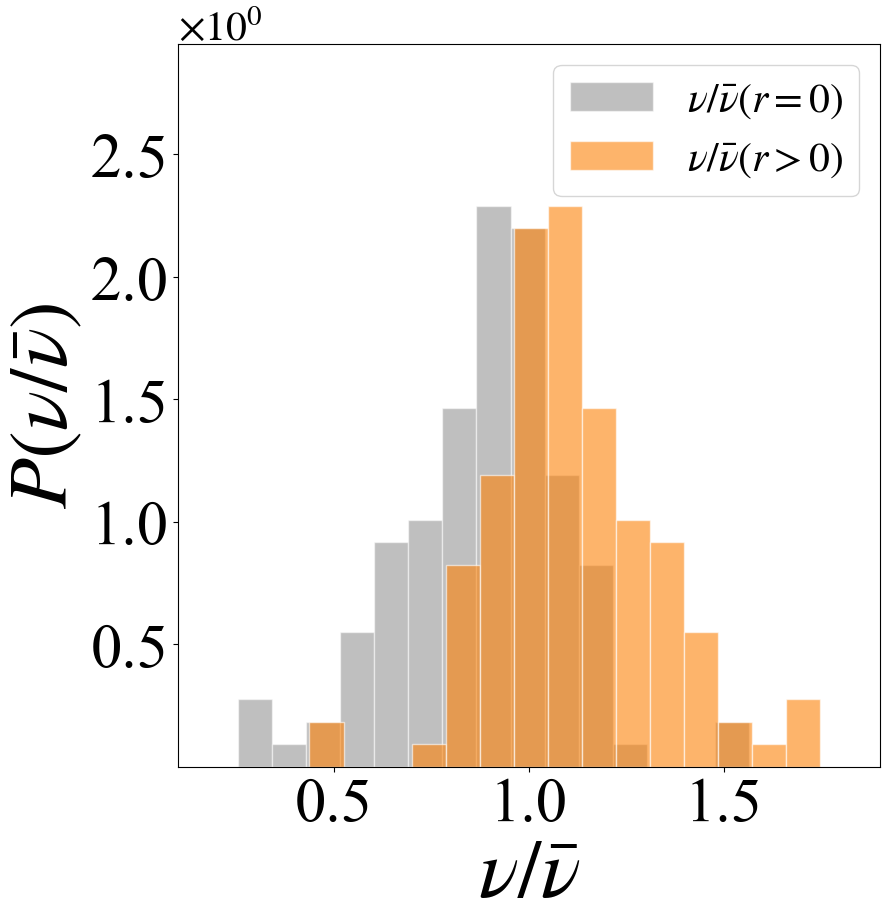

70.40%


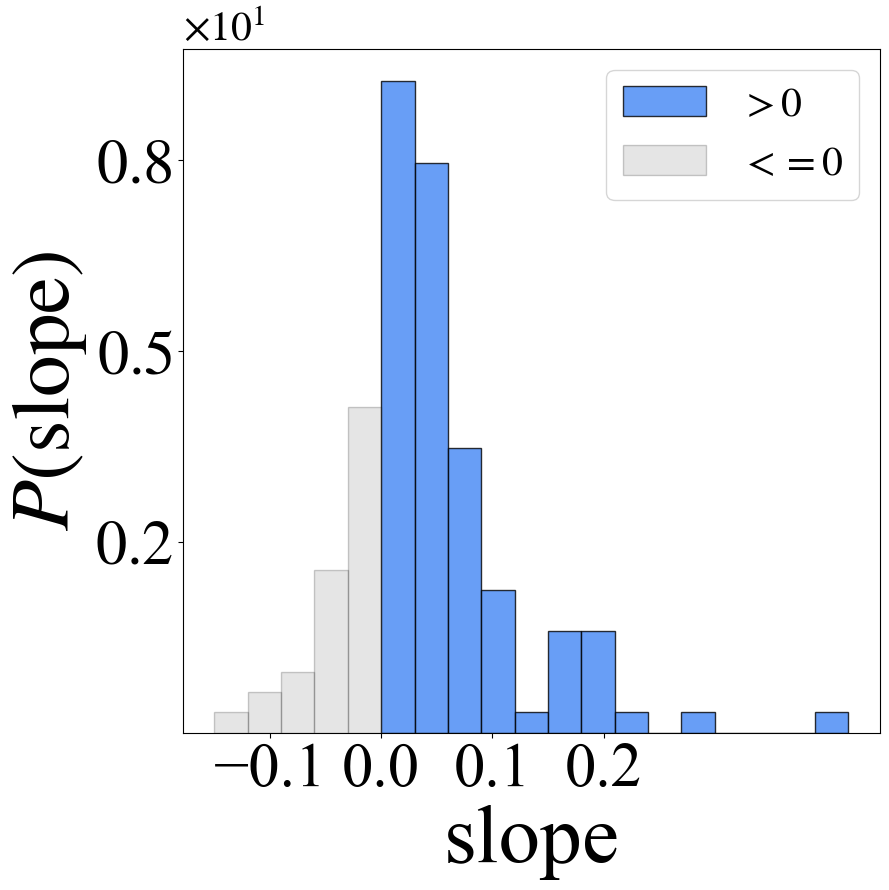

In [16]:

max_y = 2.95
fig = plot_rate_ratio_hist(*_load_ratio('patentB1'), ylim=max_y, pos_color=colorA)
plt.xlim(0.1, 1.9)
plt.xticks(fontsize=fs(30))
plt.yticks([0.5, 1.0, 1.5, 2.0, 2.5], fontsize=fs(30))
plt.ylim(0, max_y)
plt.annotate(r'$\times10^{0}$', xy=(0.1, max_y), xytext=(0.1, max_y+0.02), fontsize=fs(20))
savefig(fig, 'patentB1.pdf'); plt.show()

fig, ratio = two_color_hist(_load_slopes('patentB2'), gap=0.03, pos_color=color0, figsize=(9, 9))
plt.ylabel('$P(\mathrm{slope})$', fontsize=fs(40)); plt.xlabel('slope', fontsize=fs(40)); plt.legend(fontsize=fs(20))
plt.xticks([-0.1, 0, 0.1, 0.2], fontsize=fs(30))
sci_yaxis(xpow_x=0.0, xpow_y=1, fontsize_tick=fs(30), fontsize_ann=fs(20))
plt.tight_layout(); savefig(fig, 'patentB2.pdf'); plt.show()

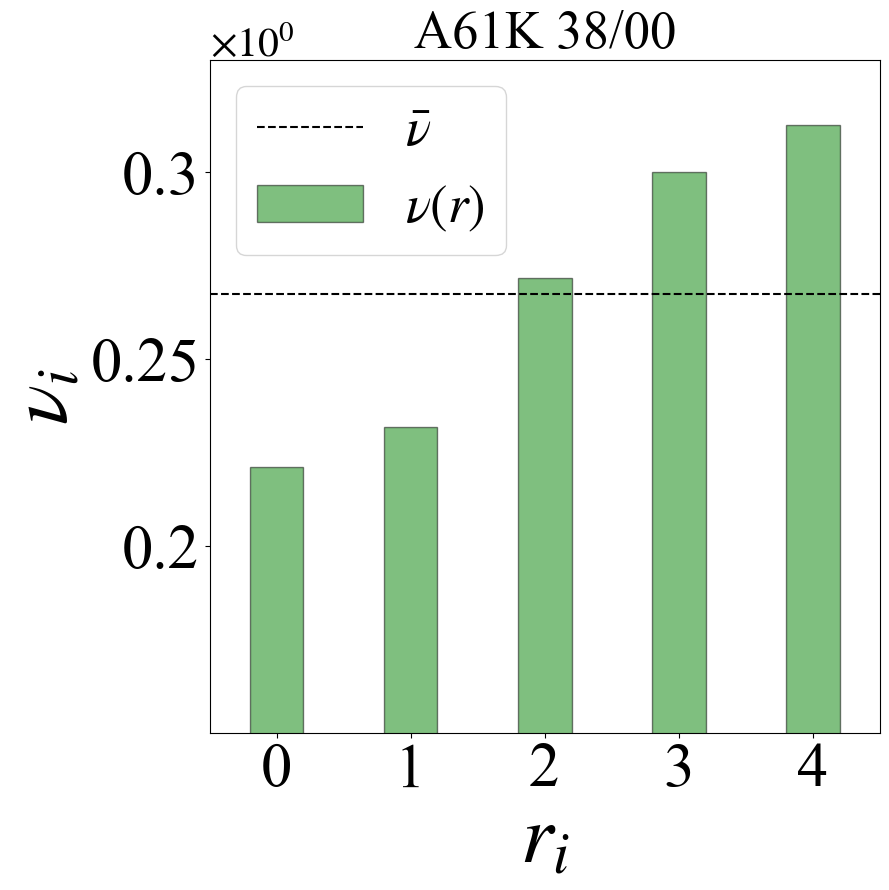

In [17]:
fig = plt.figure(figsize=(9, 9)); ax = plt.subplot(111)
xdata, ydata, av = _load_bars('patentB3')
ax.bar(xdata, moving_average(ydata, n=1), color='green', edgecolor='k',
       alpha=0.5, width=0.4, label=r'$\nu(r)$')
left, right = -0.5, 4.5
ax.plot([left, right], [av, av], 'k--', label=r'$\bar \nu$')
ax.set_title('A61K 38/00', fontsize=fs(25))
ax.set_ylabel(r'$\nu_i$', fontsize=fs(40)); ax.set_xlabel('$r_i$', fontsize=fs(40))
ax.set_ylim(0.15, 0.33); ax.set_xlim(left, right)
plt.xticks([0, 1, 2, 3, 4], fontsize=fs(30))
plt.yticks([0.2, 0.25, 0.3], ['0.2', '0.25', '0.3'], fontsize=fs(30))
ax.legend(loc=2, fontsize=fs(25))
plt.annotate(r'$\times10^{0}$', xy=(left, 0.33), xytext=(left, 0.331), fontsize=fs(20))
plt.tight_layout(); savefig(fig, 'patentB3.pdf'); plt.show()

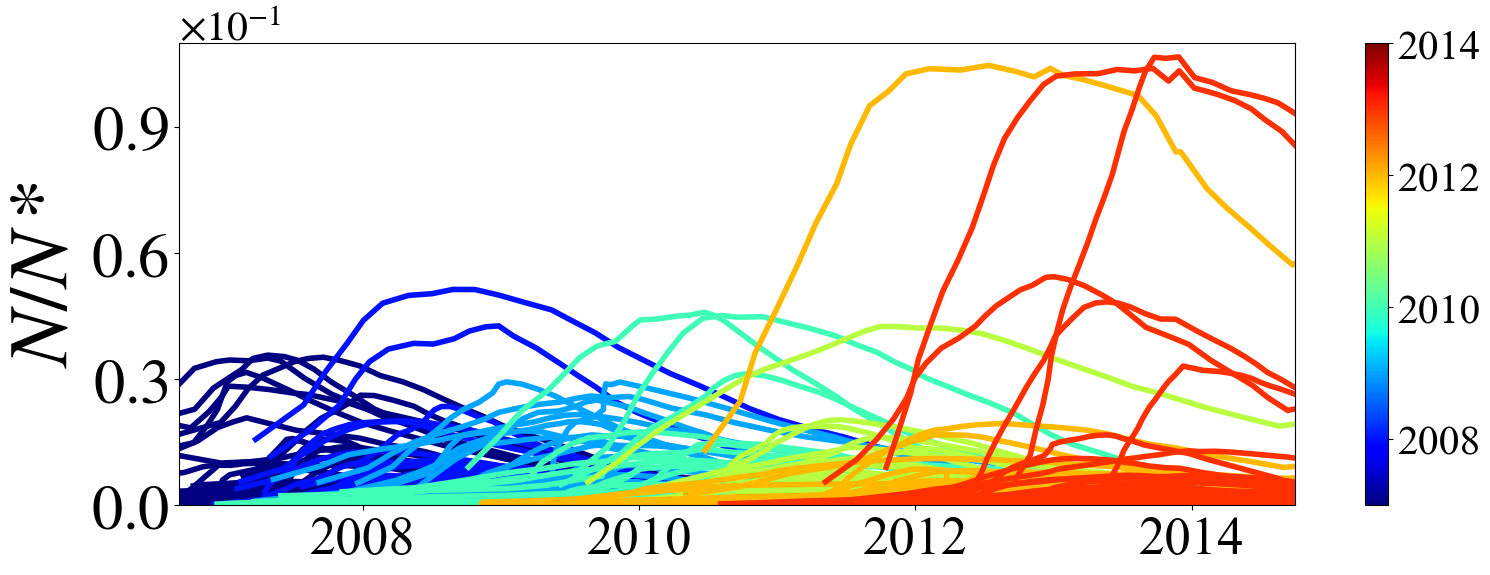

In [18]:
base = date(2005, 1, 1)
def getcm_phone(x):
    return plt.cm.jet((np.clip(x, 2007, 2014) - 2007) / 7.)

plot_all = _load_growth_dates('phoneA1')
cm = plt.cm.jet
fig, ax = plt.subplots(figsize=(18, 6))
keys = plot_all.keys()
for color in range(min(keys), max(keys)):
    if color not in plot_all:
        continue
    for xs, ys in plot_all[color]:
        ax.plot(xs, ys, color=getcm_phone(color), linewidth=4)
plt.yticks([0, 0.03, 0.06, 0.09], ['$0.0$', '$0.3$', '$0.6$', '$0.9$'], size=fs(30))
plt.xticks([date(2008,1,1), date(2010,1,1), date(2012,1,1), date(2014,1,1)], [2008, 2010, 2012, 2014], size=fs(25))
plt.xlim(date(2006, 9, 1), date(2014, 10, 1)); plt.ylim(0, 0.11)
plt.annotate(r'$\times10^{-1}$', xy=(date(2006, 9, 1), 0.11), xytext=(date(2006, 9, 1), 0.111), fontsize=fs(20))
plt.ylabel('$N/N*$', fontsize=fs(40))
sm = ScalarMappable(norm=Normalize(2007, 2014), cmap=cm); sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, format='%d')  
cbar.ax.tick_params(labelsize=fs(20))

savefig(fig, 'phoneA1.pdf'); plt.show()

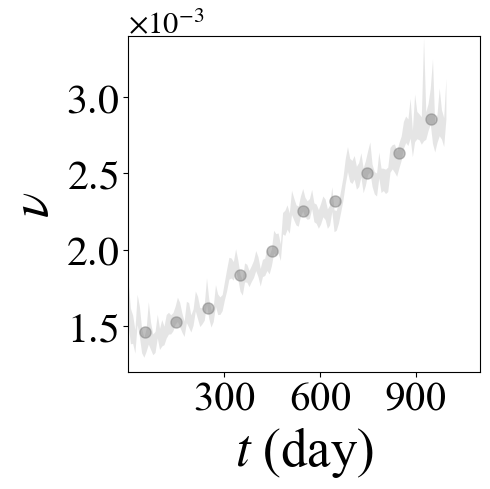

91.34%


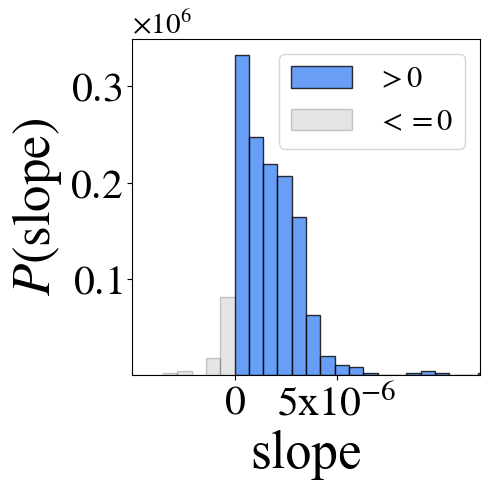

In [19]:

fig = _plot_nut('phoneA2')
plt.ylabel('$\\nu$', fontsize=fs(25)); plt.xlabel('$t$ (day)', fontsize=fs(25))
plt.xticks([300, 600, 900],fontsize=fs(20))
plt.ylim(0.0012, 0.0034)
plt.xlim(0, 1100)
plt.yticks([0.0015, 0.002,0.0025, 0.003],['$1.5$','$2.0$','$2.5$','$3.0$'],fontsize=fs(20))
plt.annotate(r'$\times10^{-3}$', xy=(0, 0.0034), xytext=(0, 0.00342), fontsize=fs(15))
plt.tight_layout(); savefig(fig, 'phoneA2.pdf'); plt.show()

fig, ratio = two_color_hist(_load_slopes('phoneA3'), gap=0.0000007, pos_color=color0, figsize=(5, 5))
plt.legend(fontsize=fs(15))
plt.xticks([0, 0.000005], ['$0$', '$5$x$10^{-6}$'], size=fs(20))
plt.ylabel('$P(\mathrm{slope})$', fontsize=fs(25)); plt.xlabel('slope', fontsize=fs(25))
plt.xlim(-0.000005, 0.000012)
sci_yaxis(xpow_x=0.0, xpow_y=1.0, fontsize_tick=fs(20), fontsize_ann=fs(14))
plt.tight_layout(); savefig(fig, 'phoneA3.pdf'); plt.show()

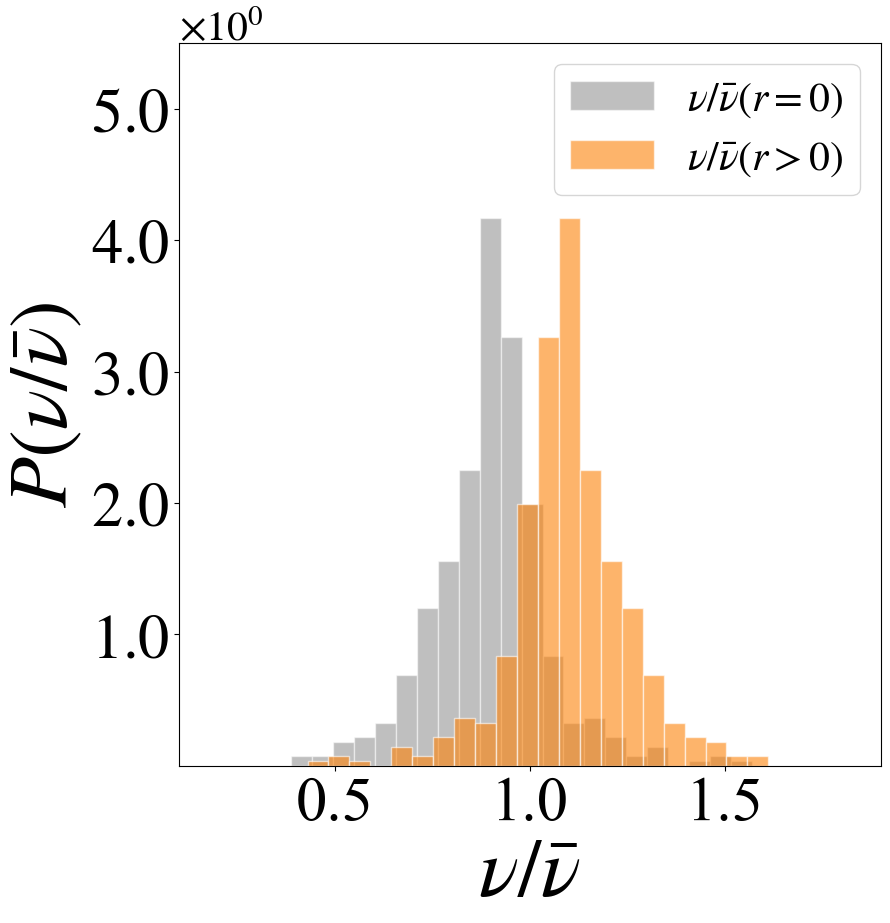

79.34%


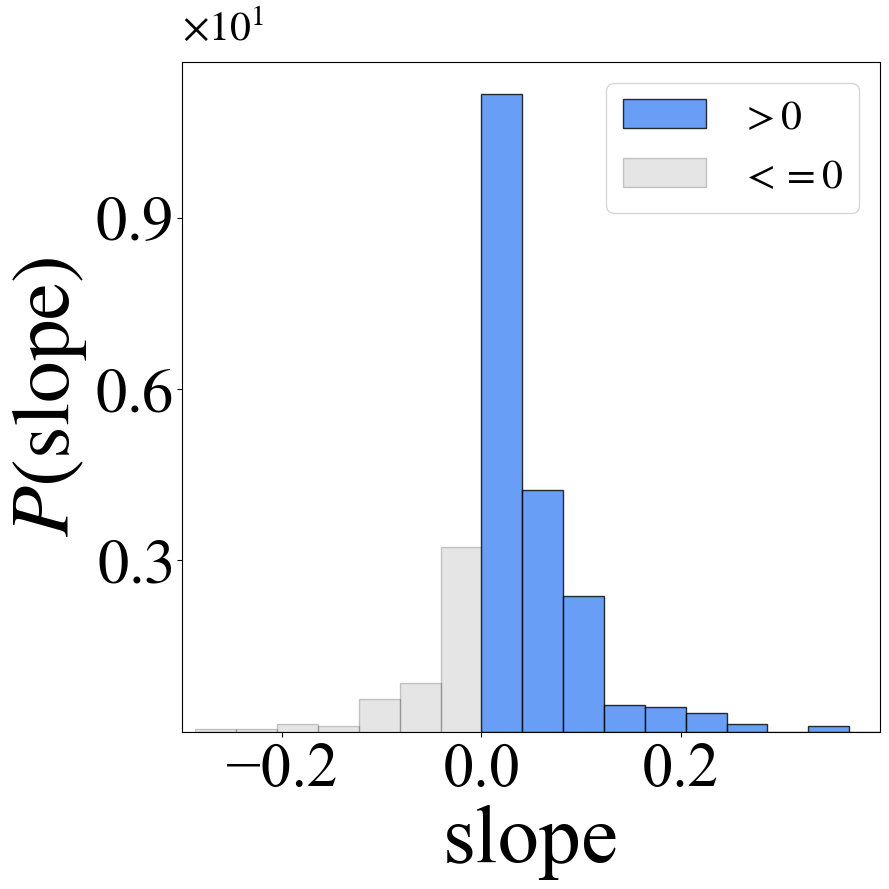

In [20]:

max_y = 5.5
fig = plot_rate_ratio_hist(*_load_ratio('phoneB1'), bins=30, ylim=max_y, pos_color=colorA)
plt.xlim(0.1, 1.9)
plt.ylim(0, max_y)
plt.xticks(fontsize=fs(30))
plt.yticks([1, 2, 3, 4, 5], ['$1.0$', '$2.0$', '$3.0$', '$4.0$', '$5.0$'], fontsize=fs(30))
plt.annotate(r'$\times10^{0}$', xy=(0.1, max_y), xytext=(0.1, max_y+0.03), fontsize=fs(20))
savefig(fig, 'phoneB1.pdf'); plt.show()

fig, ratio = two_color_hist(_load_slopes('phoneB2'), gap=0.041, pos_color=color0, figsize=(9, 9))
plt.ylabel('$P(\mathrm{slope})$', fontsize=fs(40)); plt.xlabel('slope', fontsize=fs(40)); plt.legend(fontsize=fs(20))
plt.xticks([-0.2, 0, 0.2], fontsize=fs(30))
plt.xlim(-0.3, 0.4)
sci_yaxis(xpow_x=0.0, xpow_y=1.02, fontsize_tick=fs(30), fontsize_ann=fs(20))
plt.tight_layout(); savefig(fig, 'phoneB2.pdf'); plt.show()

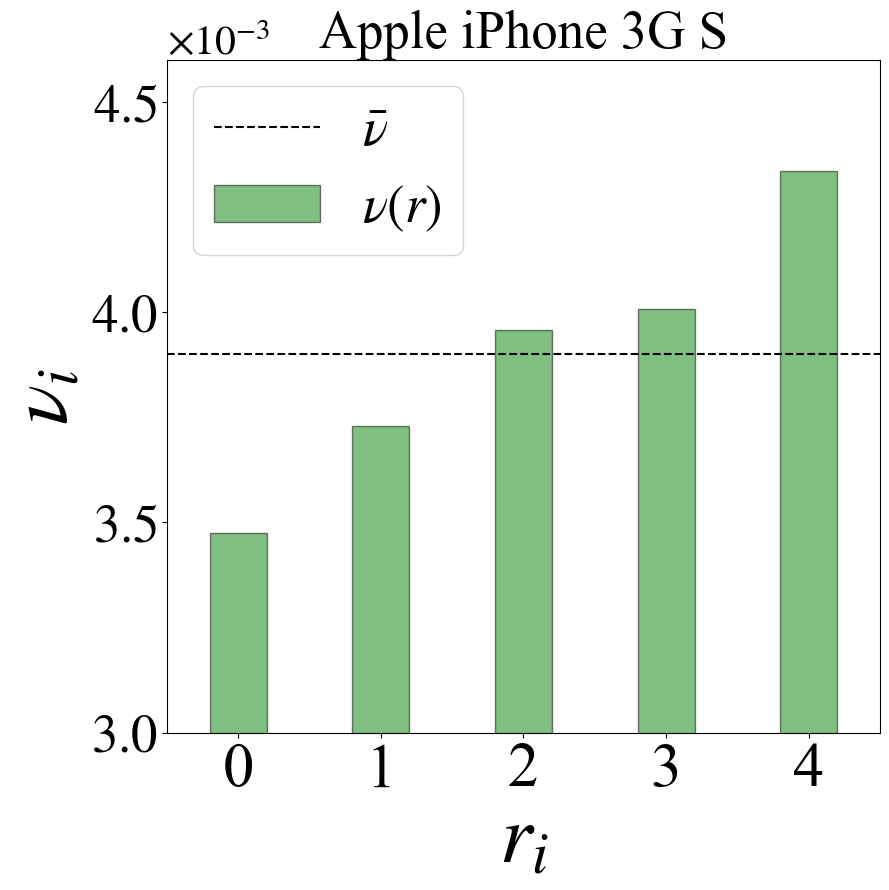

In [21]:
name = 'Apple iPhone 3G S'
fig = plt.figure(figsize=(9, 9)); ax = plt.subplot(111)
xdata, ydata, av = _load_bars('phoneB3')
ax.bar(xdata, moving_average(ydata, n=1), color='green', edgecolor='k',
       alpha=0.5, width=0.4, label=r'$\nu(r)$')
left, right = -0.5, 4.5
ax.plot([left, right], [av, av], 'k--', label=r'$\bar \nu$')
ax.set_title(name, fontsize=fs(25))
ax.set_ylabel(r'$\nu_i$', fontsize=fs(40)); ax.set_xlabel('$r_i$', fontsize=fs(40))
ax.set_ylim(0.003, 0.0046); ax.set_xlim(left, right)
plt.xticks(fontsize=fs(30))
plt.yticks([0.003, 0.0035, 0.004, 0.0045], ['$3.0$', '$3.5$', '$4.0$', '$4.5$'], size=fs(25))
plt.annotate(r'$\times10^{-3}$', xy=(left, 0.0032), xytext=(left, 0.004615), fontsize=fs(20))
ax.legend(loc=2, fontsize=fs(25))
plt.tight_layout(); savefig(fig, 'phoneB3.pdf'); plt.show()

In [22]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import rc, cm
import matplotlib.colors as mcolors
%matplotlib inline

rc('text', usetex=False)
rc('font', family='serif')
rc('font', serif=['Times New Roman', 'Times'])
mpl.rcParams['mathtext.fontset'] = 'stix'

FONT_SCALE = 1.5
SAVE_DPI   = 300
FIG_DIR    = 'Figures'
def fs(x):
    """Scale a base fontsize by FONT_SCALE (as in the main notebooks)."""
    return round(x * FONT_SCALE)
def savefig(fig, name):
    os.makedirs(FIG_DIR, exist_ok=True)
    fig.savefig(os.path.join(FIG_DIR, name), dpi=SAVE_DPI, bbox_inches='tight')

DATA = 'simulation_data'
N    = 10**6
color_rand = 'grey'
color_pref = 'firebrick'

In [23]:
def load_avg(net, alphas):
    out = {}
    for a in alphas:
        files = sorted(glob.glob(os.path.join(DATA, f'{net}_results', f'*_alpha{a:02d}_run*.csv')))
        runs = []
        for fp in files:
            df = pd.read_csv(fp).values[:, :4].astype(float)
            runs.append(df)
        if not runs:
            continue
        m = min(len(r) for r in runs)
        out[a] = np.mean([r[:m] for r in runs], axis=0)
    return out

def peakpoint(avg):
    chi = avg[:, 3]
    return avg[:, 2][int(np.argmax(chi))]

NETS = {'SF': 'A', 'ER': 'D', 'NM': 'G'}

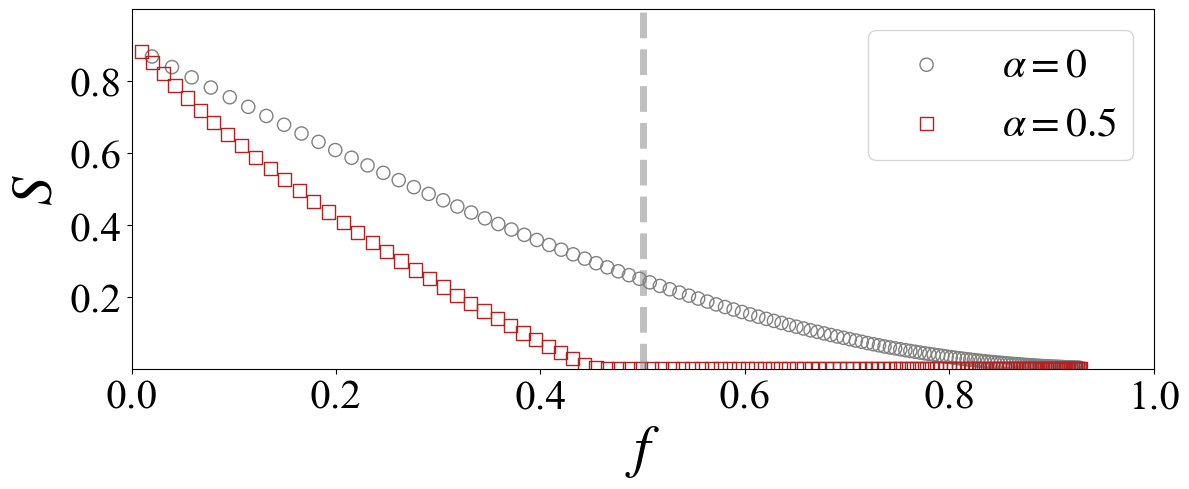

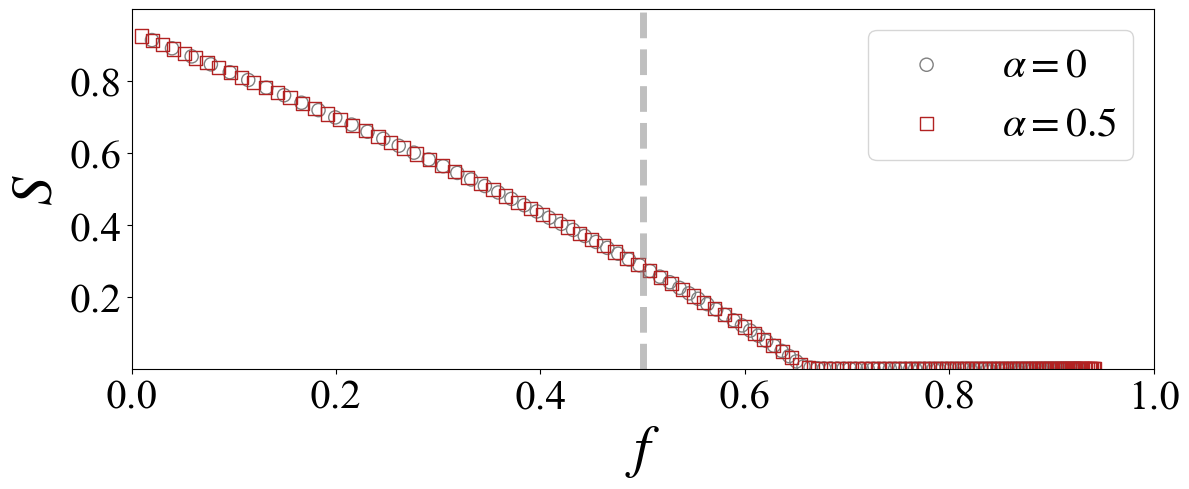

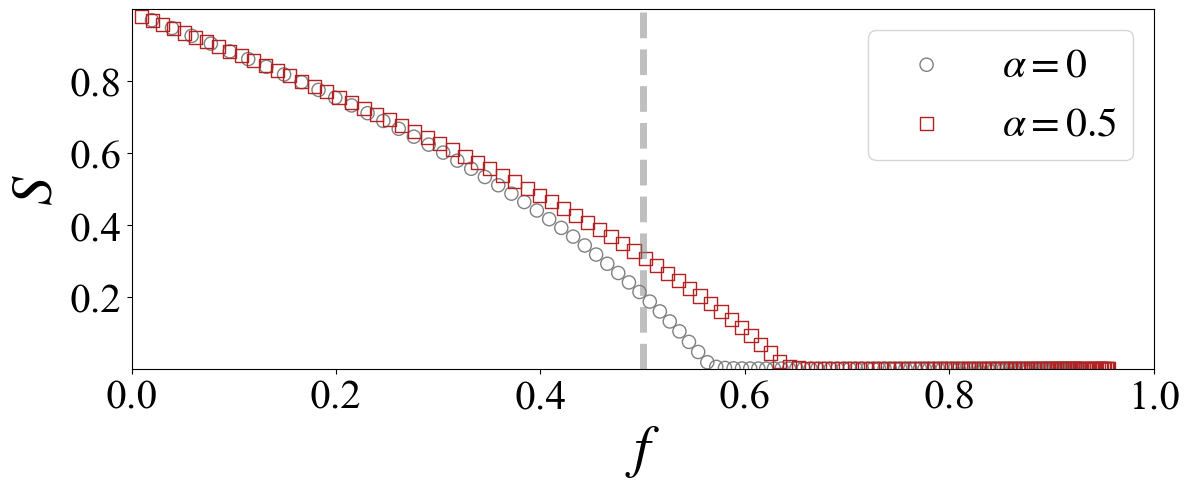

In [24]:
def plot_S_vs_f(net, panel):
    avg = load_avg(net, [0, 50])
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.axvline(0.5, color='grey', lw=5, alpha=0.5, ls='--')
    for a, c, mk, lab in [(0, color_rand, 'o', r'$\alpha = 0$'),
                          (50, color_pref, 's', r'$\alpha = 0.5$')]:
        f  = avg[a][:, 2]
        S  = avg[a][:, 0] / N
        ax.scatter(f, S, edgecolor=c, marker=mk, s=90, facecolor='none', label=lab)
    ax.set_xlabel('$f$', fontsize=fs(28)); ax.set_ylabel('$S$', fontsize=fs(28))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticks([0.2, 0.4, 0.6, 0.8])
    ax.tick_params(labelsize=fs(20)); ax.legend(fontsize=fs(20), scatterpoints=1)
    plt.tight_layout(); savefig(fig, f'Figure3{panel}.pdf'); plt.show()

for net, panel in NETS.items():
    plot_S_vs_f(net, panel)

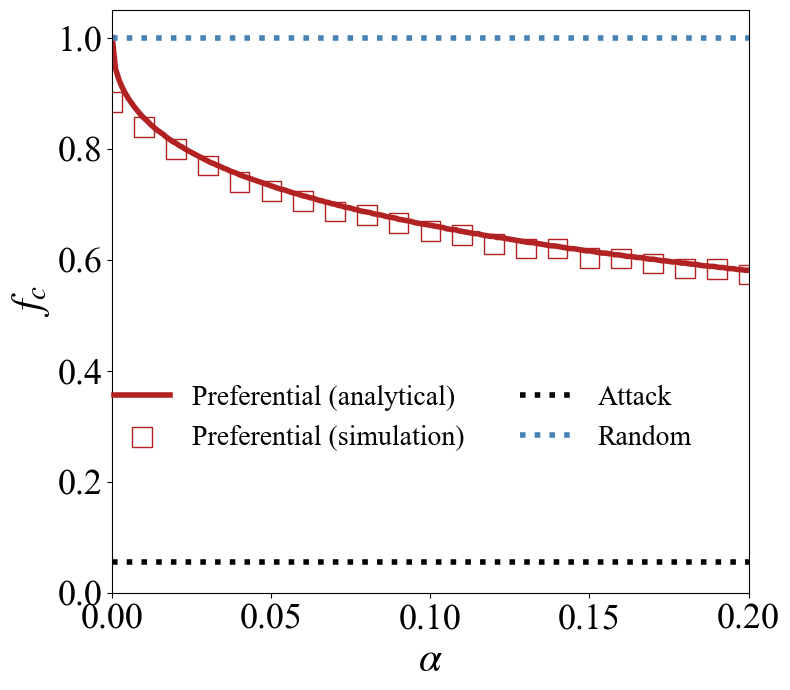

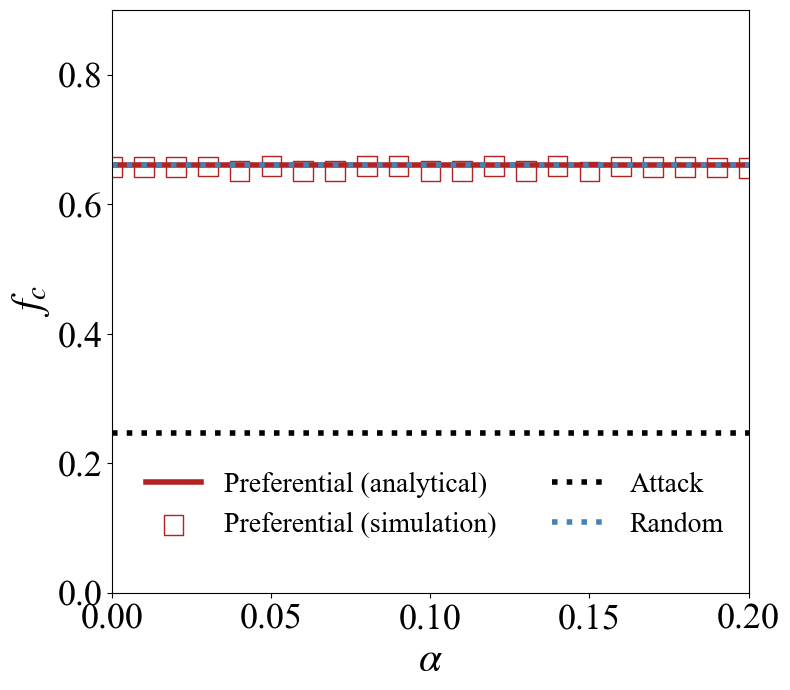

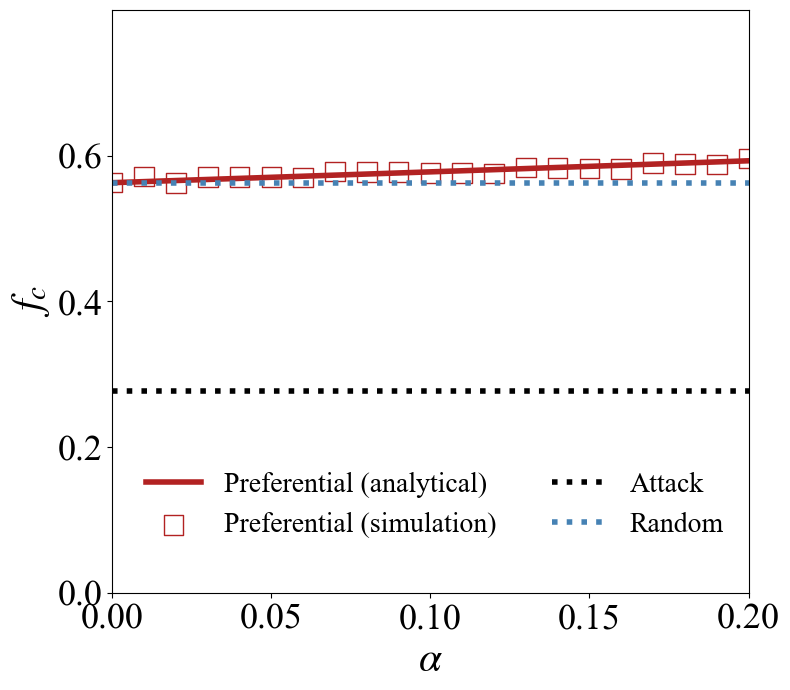

In [25]:
from scipy.integrate import solve_ivp

STATS = pd.read_csv(os.path.join(DATA, 'network_stats.csv')).set_index('network')
ALPHAS = np.linspace(0.0, 0.20, 21)
col_analytic = 'firebrick'
col_attack   = 'k'
col_random   = 'steelblue'

def load_avg_maxlen(net, a):
    files = sorted(glob.glob(os.path.join(DATA, f'{net}_results', f'*_alpha{a:02d}_run*.csv')))
    runs = [pd.read_csv(fp).values[:, :4].astype(float) for fp in files]
    L = max(len(r) for r in runs)
    return np.array([np.mean([r[i] for r in runs if i < len(r)], axis=0) for i in range(L)])

def sim_fc_curve(net):
    return np.array([[a / 100.0, peakpoint(load_avg_maxlen(net, a))] for a in range(0, 21)])

def attack_fc(net):
    peaks = []
    for fp in glob.glob(os.path.join(DATA, f'{net}_strategic_results', '*.csv')):
        d = pd.read_csv(fp).values[:, :4].astype(float)
        peaks.append(d[:, 2][int(np.argmax(d[:, 3]))])
    return float(np.mean(peaks))

def fc_vs_alpha(mu, sigma, alpha_grid):
    s2 = sigma ** 2
    g = lambda h: mu + s2 * np.log(h)
    def fc_expr(h):
        G = g(h); return 1.0 - mu * h ** 2 / (G ** 2 - G + s2)
    def dh_df(f, h, a):
        G = g(h)
        return a * ((1 - f) * G / (mu * h) - h) / \
               ((1 - f) * (a * (G - (1 - f) * G ** 2 / (mu * h ** 2)) + 1 - a))
    def one(a):
        if np.isclose(a, 0.0):
            return 1.0 - mu / (mu ** 2 - mu + s2)
        sol = solve_ivp(lambda f, h: dh_df(f, h, a), (0.0, 0.999), [1.0],
                        max_step=2e-3, rtol=1e-9, atol=1e-12)
        fv, hv = sol.t, sol.y[0]
        for k in range(1, len(fv)):
            d1 = fv[k - 1] - fc_expr(hv[k - 1]); d2 = fv[k] - fc_expr(hv[k])
            if d1 * d2 <= 0:
                return fv[k - 1] - d1 * (fv[k] - fv[k - 1]) / (d2 - d1)
        return 1.0
    return np.array([one(a) for a in alpha_grid])

def sf_analytical():
    rows = []
    with open(os.path.join(DATA, 'phase_3.txt')) as fh:
        for line in fh:
            gval, a, fc = line.split()
            if float(gval) == 2.5 and float(a) <= 0.2:
                rows.append([float(a), float(fc)])
    return np.array(rows)

def plot_fc_vs_alpha(net, panel, analytic_xy, y_random, ymax, yticks, legend_bbox):
    sim = sim_fc_curve(net)
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.plot(analytic_xy[:, 0], analytic_xy[:, 1], color=col_analytic, lw=4, label='Preferential (analytical)')
    ax.scatter(sim[:, 0], sim[:, 1], edgecolor=color_pref, marker='s', s=200,
               facecolor='none', label='Preferential (simulation)')
    ax.plot([0, 0.2], [attack_fc(net)] * 2, ls='dotted', color=col_attack, lw=4, label='Attack')
    ax.plot([0, 0.2], [y_random] * 2,       ls='dotted', color=col_random, lw=4, label='Random')
    ax.set_xlim(0, 0.2); ax.set_ylim(0, ymax)
    ax.set_xticks([0, 0.05, 0.1, 0.15, 0.2]); ax.set_yticks(yticks)
    ax.set_xlabel(r'$\alpha$', fontsize=fs(20)); ax.set_ylabel('$f_c$', fontsize=fs(20))
    ax.tick_params(labelsize=fs(17))
    ax.legend(fontsize=fs(13), bbox_to_anchor=legend_bbox, frameon=False, scatterpoints=1, ncol=2)
    plt.tight_layout(); savefig(fig, f'Figure3{panel}.pdf'); plt.show()

mu_ER = STATS.loc['ER', 'mu']; mu_NM = STATS.loc['NM', 'mu']

plot_fc_vs_alpha('SF', 'B', sf_analytical(), 1.0, 1.05, [0, 0.2, 0.4, 0.6, 0.8, 1.0], [0.45, 0, 0.5, 0.4])

er_line = np.array([[0, 1 - 1 / mu_ER], [0.2, 1 - 1 / mu_ER]])
plot_fc_vs_alpha('ER', 'E', er_line, 1 - 1 / mu_ER, 0.9, [0, 0.2, 0.4, 0.6, 0.8], [0, 0.05, 1, 0.2])

nm_fc = fc_vs_alpha(mu_NM, 1.0, ALPHAS)
plot_fc_vs_alpha('NM', 'H', np.column_stack([ALPHAS, nm_fc]), nm_fc[0], 0.8, [0, 0.2, 0.4, 0.6], [0, 0.05, 1, 0.2])

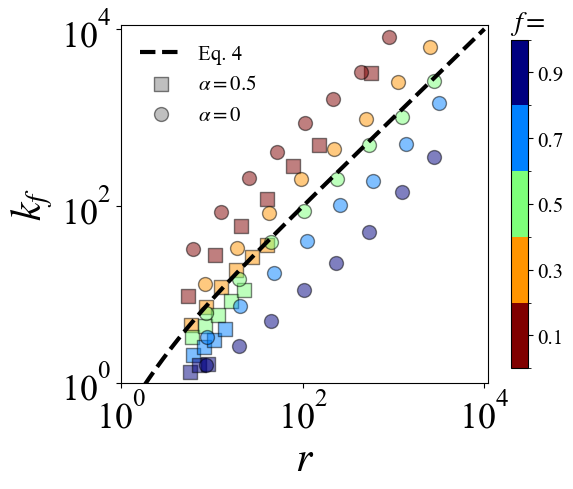

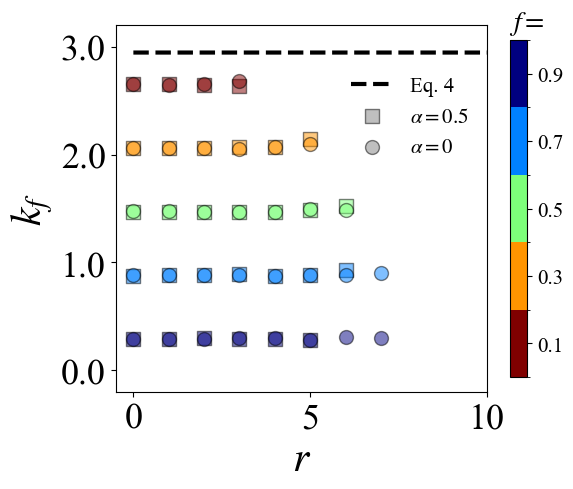

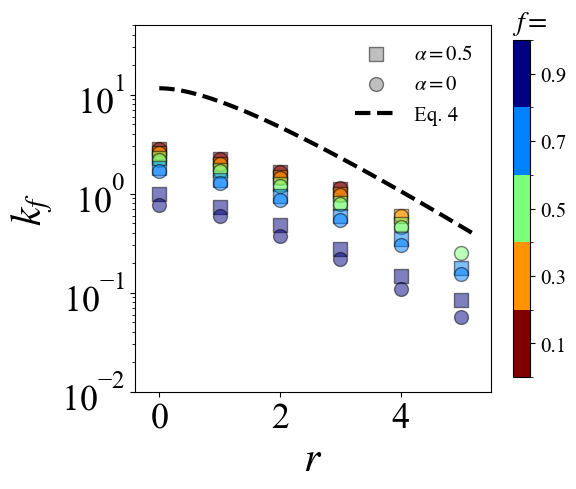

In [26]:
from binning import log_binningtwo
from scipy import stats

FRAS   = [1, 3, 5, 7, 9]
F_VALS = [0.1, 0.3, 0.5, 0.7, 0.9]
_bounds = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
_cmap = cm.jet_r
_norm = mcolors.BoundaryNorm(_bounds, _cmap.N)

def load_kr(net):
    d = np.load(os.path.join(DATA, f'{net}_kr.npz'))
    return ({fr: d[f'pref_{fr}'] for fr in FRAS},
            {fr: d[f'rand_{fr}'] for fr in FRAS})

def _fbar(fig, ax):
    cbar = fig.colorbar(cm.ScalarMappable(norm=_norm, cmap=_cmap), ax=ax, shrink=0.92, aspect=20)
    cbar.set_ticks(F_VALS); cbar.set_ticklabels(F_VALS); cbar.ax.tick_params(labelsize=fs(10))
    cbar.ax.text(1, 1.05, '$f=$', transform=cbar.ax.transAxes, ha='center', va='center', fontsize=fs(13))

def _legend_markers(ax):
    ax.scatter([], [], marker='s', facecolor='grey', edgecolor='k', s=100, alpha=0.5, label=r'$\alpha = 0.5$')
    ax.scatter([], [], marker='o', facecolor='grey', edgecolor='k', s=100, alpha=0.5, label=r'$\alpha = 0$')

def plot_C():
    pref, rand = load_kr('SF')
    fig, ax = plt.subplots(figsize=(6, 5))
    x = np.linspace(0.1, 10000, 500000)
    ax.plot(x, np.power((1 + 1 / x), -2.5) * (x + 1), 'k--', lw=3, label='Eq. 4')
    def binned(arr):
        xn, ym = log_binningtwo([p[1] + 1 for p in arr], [p[0] + 1 for p in arr], 10)
        n = len([v for v in xn if v < 5]); return xn[n:], ym[n:]
    for fr, fv in zip(FRAS, F_VALS):
        c = _cmap(_norm(fv))
        xn, ym = binned(pref[fr]); ax.scatter(xn, ym, marker='s', facecolor=c, edgecolor='k', s=100, alpha=0.5)
        xn, ym = binned(rand[fr]); ax.scatter(xn, ym, marker='o', facecolor=c, edgecolor='k', s=100, alpha=0.5)
    _legend_markers(ax)
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(1, 1.1e4); ax.set_ylim(1, 1.1e4)
    ax.set_xlabel('$r$', fontsize=fs(20)); ax.set_ylabel('$k_f$', fontsize=fs(20))
    ax.tick_params(labelsize=fs(17)); ax.legend(fontsize=fs(10), loc='upper left', frameon=False, numpoints=1)
    _fbar(fig, ax); plt.tight_layout(); savefig(fig, 'Figure3C.pdf'); plt.show()

def plot_F():
    pref, rand = load_kr('ER')
    k = STATS.loc['ER', 'mu']
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(np.linspace(0, 10, 5000), [k] * 5000, 'k--', lw=3, label='Eq. 4')
    def gb(arr):
        df = pd.DataFrame(arr, columns=['current', 'abandon'])
        m = df.groupby('abandon')['current'].mean(); c = df.groupby('abandon')['current'].count()
        idx = [i for i in m.index if c[i] > 500]; return idx, [m[i] for i in idx]
    for fr, fv in zip(FRAS, F_VALS):
        col = _cmap(_norm(fv))
        xi, yi = gb(pref[fr]); ax.scatter(xi, yi, marker='s', facecolor=col, edgecolor='k', s=100, alpha=0.5)
        xi, yi = gb(rand[fr]); ax.scatter(xi, yi, marker='o', facecolor=col, edgecolor='k', s=100, alpha=0.5)
    _legend_markers(ax)
    ax.set_xlim(-0.5, 10); ax.set_ylim(-0.2, 3.2); ax.set_yticks([0, 1, 2, 3]); ax.set_yticklabels(['0.0', '1.0', '2.0', '3.0'])
    ax.set_xlabel('$r$', fontsize=fs(20)); ax.set_ylabel('$k_f$', fontsize=fs(20))
    ax.tick_params(labelsize=fs(17)); ax.legend(fontsize=fs(10), loc='upper right', bbox_to_anchor=(1.0, 0.912), frameon=False, numpoints=1)
    _fbar(fig, ax); plt.tight_layout(); savefig(fig, 'Figure3F.pdf'); plt.show()

def plot_I():
    pref, rand = load_kr('NM')
    mu, sigma = STATS.loc['NM', 'mu'], 1.0
    fig, ax = plt.subplots(figsize=(6, 5))
    def gb(arr):
        df = pd.DataFrame(arr, columns=['current', 'abandon'])
        m = df.groupby('abandon')['current'].mean(); c = df.groupby('abandon')['current'].count()
        idx = [i for i in m.index if c[i] > 500]; return idx, [m[i] for i in idx]
    for fr, fv in zip(FRAS, F_VALS):
        col = _cmap(_norm(fv))
        xi, yi = gb(pref[fr]); ax.scatter(xi, yi, marker='s', facecolor=col, edgecolor='k', s=100, alpha=0.5)
        xi, yi = gb(rand[fr]); ax.scatter(xi, yi, marker='o', facecolor=col, edgecolor='k', s=100, alpha=0.5)
    _legend_markers(ax)
    x = np.linspace(0, 5.2, 100)
    y, y1 = stats.norm.pdf(x, mu, sigma), stats.norm.pdf(x + 1, mu, sigma)
    ax.plot(x, [y1[i] / y[i] * (x[i] + 1) for i in range(len(y))], 'k--', lw=3, label='Eq. 4')
    ax.set_yscale('log'); ax.set_xlim(-0.4, 5.5); ax.set_ylim(0.01, 50)
    ax.set_xlabel('$r$', fontsize=fs(20)); ax.set_ylabel('$k_f$', fontsize=fs(20))
    ax.tick_params(labelsize=fs(17)); ax.legend(fontsize=fs(10), loc='upper right', frameon=False, numpoints=1)
    _fbar(fig, ax); plt.tight_layout(); savefig(fig, 'Figure3I.pdf'); plt.show()

plot_C(); plot_F(); plot_I()